<a href="https://www.kaggle.com/code/isissantoscosta/divvy-analytics?scriptVersionId=348477209" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#### <a id='top'></a>
Created: [Apr 02, 2024](https://www.kaggle.com/code/isissantoscosta/google-capstone-bikeshare-quick-analysis) &nbsp;•&nbsp; Updated: Sep 09, 2026 &nbsp;•&nbsp; by [Ísis Santos Costa](https://www.linkedin.com/in/isis-santos-costa/) 👩‍💻🤖 (AI-Assisted)  

<hr>

**« How to turn users into subscribers? »**

This is a question **businesses** constantly grapple with, especially **Marketing** and **Product** teams in **SaaS** companies aiming to promote **usage that increases revenue**, particularly measured as annual recurring revenue (**ARR**). This sort of challenge was proposed as a [**Capstone Project**](https://www.coursera.org/learn/google-data-analytics-capstone/) of the [**Google Data Analytics Professional Certificate**](https://www.coursera.org/professional-certificates/google-data-analytics/) curriculum, which this project addresses.  

---
The data used in this project is available as a Kaggle dataset on [**🚲 Divvy・Dataset**](https://www.kaggle.com/datasets/isissantoscosta/divvy-tripdata/).

<a id='executive_summary'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:left; font-weight:regular; overflow:hidden"><strong>Executive Summary</strong></div>

Cyclistic is a **fictional bikeshare system** that allows users to rent a bike from a station and return it to any other station within the system, catering to both **leisure** and **transportation** needs.  

Their available pricing plans include:  
* Single-ride pass (_casual riders_)
* Full-day pass (_casual riders_)
* Annual membership (_members_ / _subscribers_)

The Finance team at Cyclistic reported that **subscribers** are considerably **more profitable** than casual riders. Responding to that, the Marketing department is now focused on increasing the **number of memberships**. Specifically, in order to leverage the lowest activation cost at hand, the chosen strategy is to **convert casual riders into subscribers**. This report presents the analysis and recommendations by the **Product Data** team to support the mentioned Marketing initiatives, in light of the insights by the Finance team.  

- **Problem**: Casual users are under-monetized.  
- **Goal**: Turn casual users into subscribers.  
- **Hypothesis**: Casual users behaving like subscribers are easier to convert.  
- **Method**: From **_members_' predominant behavior** identify an ICP (Ideal Customer Profile), then **score _casual users_** by similarity.  
- **Recommendation**: Target casual users having a high ICP-score with offers/campaigns.  
- **Impact**: Conversion of casual user → higher profitability.

---

This document is designed for a two-track navigation:
- **Business Track**:  
  [Executive Summary](#executive_summary) → [Identify the ICP](#icp) → [Find casual users with a high ICP-score](#action) (5-7 min read)
- **Technical Track**:  
  Full project, with [Data Quality](#data_quality), [Canonical entity mapping](#canonicalization), [Modular Design](#modular_design), and analytical discussion (15-20 min read)

<hr>

<a id="contents"></a>
# <strong>Contents</strong>  
[**Executive Summary**](#executive_summary)  
[**Step 1**: Business questions](#business_questions)  
[**Step 2**: Data collection](#data_collection)  
[**Step 3**: Data prep](#data_prep)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [⧗ Load](#loading)    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [⌕ Inspect](#inspecting)    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [𖤘 Type cast](#type_casting)   
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [**✓** Ensure **_Data Quality_**](#data_quality)     
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [**⇄** **_Canonical entity mapping_**](#canonicalization)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ _in_ [_modular design_](#modular_design)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [🛈 Describe](#describing)    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [⛯ Engineer features](#feature_engineering)    
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [≡ Model 🗲 **_Dimensional Modeling_**](#dimensional_modeling)   
[**Step 4**: Analysis](#analysis)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [⦿ Identify the Ideal Customer Profile (ICP)](#icp)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↳ [◇ Find casual users with a high ICP-score](#high_icp)  
[**Step 5**: Action](#action)  
[References](#references)  
[Annex: User upgrade strategies](#annex)  
[Takeaways](#takeaways)  

<hr>

<a id='business_questions'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:center; font-weight:regular; overflow:hidden"><strong>Step 1 • Business questions</strong></div>

As mentioned in the [Executive Summary](#executive_summary) above, the **business outcome** targeted in this project is to **increase the number of subscribers**, pointed out by Finance as more profitable than casual users. Seeking efficient wins, the Marketing team chooses to start by **converting casual users into subscribers**. 

This leads to the following driving question:

> **How to convert casual users into subscribers?**

<br> 

With a customer-centric perspective added, the query goes through:

> **How do annual members and casual riders use our services differently?**

<br>

Focusing on operational actionability, the **Product Data** team unpacks the latter into the following:

1. **When** do members typically rent a bike versus when casual users do?
2. **What is the duration** of member rides versus casual rides?
3. **Where** do members ride versus where do casual users?

Together, these three questions—with the hypothesis that similar behavior increases conversion—answer our core actionable question:
> **Who** are the casual riders with the highest likelihood of becoming subscribers?  
> (**Who** are the casual users with the highest ICP score?)  
> ↳ _Let's reach out to them!_

<br>

[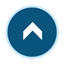](#contents)

<a id='data_collection'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:center; font-weight:regular; overflow:hidden"><strong>Step 2 • Data collection</strong></div>

The data used in this notebook are available as a Kaggle dataset on [**🚲 Divvy・Dataset**](https://www.kaggle.com/datasets/isissantoscosta/divvy-tripdata/), and consists of real operational data made available by the operators of Chicago's bike share system.

**Dataset Overview:** The “[Chicago Bikeshare Dataset](https://www.kaggle.com/datasets/isissantoscosta/divvy-tripdata/)” consists of anonymized monthly trip data from the Lyft Bikes and Scooters LLC operation of the City of Chicago’s Divvy bicycle sharing service.

**Data Science & Analytics Applications:** This dataset is recommended for Track A of the [Google Data Analytics Capstone Project](https://www.coursera.org/learn/google-data-analytics-capstone). It is valuable for analysts aiming to perform descriptive analysis, spatial analysis, trend visualization, and predictive modeling using real app data from bike-sharing services.

**The Data:** Each anonymized trip record includes:

- Trip start date and time
- Trip end date and time
- Trip start station, with its coordinates
- Trip end station, with its coordinates
- Rider type: `member`|`casual`
- Rideable type: `electric_bike`|`classic_bike`・legacy: `docked_bike`|`electric_scooter`

According to the data provider, Lyft:

> The data has been processed to exclude trips taken by staff for system servicing and inspection.  
> It also excludes any trip below 60 seconds (potentially false starts or users attempting to re-dock a bike for security).

**Data License Agreement:** https://divvybikes.com/data-license-agreement. 

**Acknowledgments:** Special thanks to Lyft Bikes and Scooters, LLC and The City of Chicago for making this data publicly available. 

**Source:** Lyft Bikes and Scooters, LLC [🔗](https://divvy-tripdata.s3.amazonaws.com/index.html)

<br>

[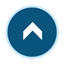](#contents)

<a id='data_prep'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:center; font-weight:regular; overflow:hidden"><strong>Step 3 • Data prep</strong></div>


<a id='loading'></a>

## ⧗ Loading the data

In [1]:
# ⧗ Loading the data

# --- Packages ---
import uuid
import pandas            as pd    # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy             as np    # linear algebra
import matplotlib.pyplot as plt   # dataviz (lower-level)
import seaborn           as sns   # dataviz (higher-level, advanced statistical plotting with automatic styling and minimal code)

import missingno         as msno  # visualize missing data
from datetime        import timedelta    # datetime operations
from collections     import defaultdict  # dict with default value
from IPython.display import display, display_markdown, HTML  # pretty print

from pandas.api.types import CategoricalDtype  # to define month and day_of_week text as sorted categories

!pip install --upgrade notebook jupyterlab -q --no-deps

!pip install mermaid-python -qqq  # programmatic interface for generating diagrams and visualizations
from mermaid import Mermaid       # used in section 3. Data prep > Dimensional Modeling > Conceptual Data Model

from awesome_ui import display_fit_to_width  # 💡 authored function for convenient df display

# --- Load ---
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/divvy-tripdata/divvy-tripdata.csv


[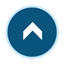](#contents)

<a id='inspecting'></a>

## ⌕ Inspecting the data

The goal of this step is to explore the dataset for:
* its general content
* columns, column labels, column data types

This is following performed with the use of pandas methods `df.head()`, and `df.info()`, respectively, after turning the `divvy-tripdata.csv` file into a pandas `DataFrame`:

In [2]:
# Check the first rows
df = pd.read_csv('/kaggle/input/divvy-tripdata/divvy-tripdata.csv')
display_markdown('#### Data • First rows<br>', raw=True)
display_fit_to_width(df.head(), index_width=10)

# Check the type of each column, and the total number of records
display_markdown('#### Column types and overall number of records<br>', raw=True)
df.info()

#### Data • First rows<br>

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9340B064F0AEE130,electric_bike,2023-07-23 20:06:14,2023-07-23 20:22:44,Kedzie Ave & 110th St,20204,Public Rack - Racine Ave & 109th Pl,877,41.692406,-87.700905,41.694835,-87.653041,member
1,D1460EE3CE0D8AF8,classic_bike,2023-07-23 17:05:07,2023-07-23 17:18:37,Western Ave & Walton St,KA1504000103,Milwaukee Ave & Grand Ave,13033,41.898418,-87.686596,41.891578,-87.648384,member
2,DF41BE31B895A25E,classic_bike,2023-07-23 10:14:53,2023-07-23 10:24:29,Western Ave & Walton St,KA1504000103,Damen Ave & Pierce Ave,TA1305000041,41.898418,-87.686596,41.909396,-87.677692,member
3,9624A293749EF703,electric_bike,2023-07-21 08:27:44,2023-07-21 08:32:40,Racine Ave & Randolph St,13155,Clinton St & Madison St,TA1305000032,41.884112,-87.656943,41.882752,-87.641190,member
4,2F68A6A4CDB4C99A,classic_bike,2023-07-08 15:46:42,2023-07-08 15:58:08,Clark St & Leland Ave,TA1309000014,Montrose Harbor,TA1308000012,41.967088,-87.667291,41.963982,-87.638181,member


#### Column types and overall number of records<br>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11900875 entries, 0 to 11900874
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 1.2+ GB


[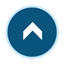](#contents)

<a id='type_casting'></a>

## 𖤘 Setting appropriate data types

The initial inspection of the dataset columns with `df.info()`, presented above, reveals that some of them are not originally in the ideal type for data analysis:

| Column          | Current Type   | Target Type   |
| ---             | ---            | ---           |
| `started_at`    | `object`       | `datetime`    |
| `ended_at`      | `object`       | `datetime`    |
| `rideable_type` | `object`       | `category`    |
| `member_casual` | `object`       | `category`    |

<br>

For performance and memory usage, high-cardinality fields (those with a large number of distinct values) are kept as `object` rather than being converted to `category`.  

In addition, the business questions addressed in this project are outlined below, and the dataset is filtered to include only the relevant columns:

1. **When** do members typically rent a bike versus when do casual users? `started_at`, `ended_at`
2. **What is the duration** of member rides versus casual rides? `started_at`, `ended_at`
3. **Where** do members ride versus where do casual users? `start_lat`, `start_lng`, `end_lat`, `end_lng`, `start_station_id`, `end_station_id`, `start_station_name`, `end_station_name`

Focusing on efficiency, the dataframe is following reduced to just these variables, besides the `ride_id` and the `member_casual` dimension. 

In [3]:
# Efficiency

df = df[[ 'ride_id'                  \
        , 'member_casual'                          \
        , 'start_station_id'  , 'end_station_id'   \
        , 'start_station_name', 'end_station_name' \
        , 'started_at'        , 'ended_at'         \
        , 'start_lat'         , 'end_lat'          \
        , 'start_lng'         , 'end_lng'          ]]

display_markdown("**Data subset, with only the columns to be used in the project**<br>", raw=True)
display_fit_to_width(df.head(), index_width=10)

display_markdown("Conversion to the analytically convenient data types is performed below:<br>", raw=True)

# Type cast

# Define types
DATETIME_COLS = ['started_at', 'ended_at']
CATEGORY_COLS = ['member_casual']

# Convert datetimes one-by-one to avoid duplicating full-DataFrame memory blocks
for col in DATETIME_COLS:
    df[col] = pd.to_datetime(df[col])

# Convert categories in-place
for col in CATEGORY_COLS:
    df[col] = df[col].astype('category')

# Display
display_markdown('**Column types, after transformation**<br>', raw=True)
df.info()

**Data subset, with only the columns to be used in the project**<br>

,ride_id,member_casual,start_station_id,end_station_id,start_station_name,end_station_name,started_at,ended_at,start_lat,end_lat,start_lng,end_lng
0,9340B064F0AEE130,member,20204,877,Kedzie Ave & 110th St,Public Rack - Racine Ave & 109th Pl,2023-07-23 20:06:14,2023-07-23 20:22:44,41.692406,41.694835,-87.700905,-87.653041
1,D1460EE3CE0D8AF8,member,KA1504000103,13033,Western Ave & Walton St,Milwaukee Ave & Grand Ave,2023-07-23 17:05:07,2023-07-23 17:18:37,41.898418,41.891578,-87.686596,-87.648384
2,DF41BE31B895A25E,member,KA1504000103,TA1305000041,Western Ave & Walton St,Damen Ave & Pierce Ave,2023-07-23 10:14:53,2023-07-23 10:24:29,41.898418,41.909396,-87.686596,-87.677692
3,9624A293749EF703,member,13155,TA1305000032,Racine Ave & Randolph St,Clinton St & Madison St,2023-07-21 08:27:44,2023-07-21 08:32:40,41.884112,41.882752,-87.656943,-87.641190
4,2F68A6A4CDB4C99A,member,TA1309000014,TA1308000012,Clark St & Leland Ave,Montrose Harbor,2023-07-08 15:46:42,2023-07-08 15:58:08,41.967088,41.963982,-87.667291,-87.638181


Conversion to the analytically convenient data types is performed below:<br>

**Column types, after transformation**<br>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11900875 entries, 0 to 11900874
Data columns (total 12 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   member_casual       category      
 2   start_station_id    object        
 3   end_station_id      object        
 4   start_station_name  object        
 5   end_station_name    object        
 6   started_at          datetime64[ns]
 7   ended_at            datetime64[ns]
 8   start_lat           float64       
 9   end_lat             float64       
 10  start_lng           float64       
 11  end_lng             float64       
dtypes: category(1), datetime64[ns](2), float64(4), object(5)
memory usage: 1010.1+ MB


[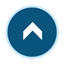](#contents)

<a id='data_quality'></a>

## **✓** Ensuring Data Quality

The **value** of **insights derived from data** relies on its underlying **quality**. For data-driven decision-making, transparency in data processing is crucial for trust and confidence in the conclusions presented.  

Multiple **frameworks** exist to ensure data quality from raw records to final insights. This project adopts a compact version of the comprehensive methodology presented by [**The Data Management Association (DAMA)**](https://www.dama.org/) in its [**Data Management Body of Knowledge (DMBoK)**](https://technicspub.com/dmbok2/). DAMA's DMBoK is recognized as the leading guide for international data management standards and practices, built on the hands-on expertise of seasoned professionals.

Specifically, **open access documents** by the [Nederland Chapter of DAMA International](https://dama-nl.org/), prepared by data quality auditing firm «&nbsp;[Van Nederpelt](https://www.linkedin.com/in/petervannederpelt/) & [Black](https://www.linkedin.com/in/andrewblackeu/)&nbsp;,» are here applied:

* **Dimensions of Data Quality (DDQ)** [🔗](https://www.dama-nl.org/wp-content/uploads/2020/09/DDQ-Dimensions-of-Data-Quality-Research-Paper-version-1.2-d.d.-3-Sept-2020.pdf)
* Code for Information Quality 2020 [🔗](https://www.dama-nl.org/wp-content/uploads/2020/02/Code-for-Information-Quality-2020-DAMA-EN_2_1.pdf)

Out of the sixty data quality dimensions presented in the DDQ document, this notebook focuses on a subset of six universal dimensions, identified by the acronym **CutCVA**:  

<p style="font-size:36px; margin-bottom:0.5em;">
    C<span style="font-size:21px;">heck    </span> 
    u<span style="font-size:21px;">p,      </span> 
    t<span style="font-size:21px;">hen     </span> 
    C<span style="font-size:21px;">onfirm: </span> 
    V<span style="font-size:21px;">alidate,</span> 
    A<span style="font-size:21px;">lways.  </span>
</p>

&nbsp;&nbsp;&nbsp;&nbsp;☐ **C** ompleteness  
&nbsp;&nbsp;&nbsp;&nbsp;☐ **u** niqueness  
&nbsp;&nbsp;&nbsp;&nbsp;☐ **t** imeliness  
&nbsp;&nbsp;&nbsp;&nbsp;☐ **C** onsistency  
&nbsp;&nbsp;&nbsp;&nbsp;☐ **V** alidity  
&nbsp;&nbsp;&nbsp;&nbsp;☐ **A** ccuracy  

The [University of Michigan **Total Data Quality** Specialization](https://online.umich.edu/series/total-data-quality/) emphasizes that the **practical objective** of Data Quality is to ensure data are **fit for purpose**: Conclusions drawn from the variables of interest reliably reflect reality. Pursuing perfect quality across every dimension is often impractical and economically unjustified. This pragmatic perspective guides the work presented here. The following sections show how the key Data Quality dimensions are assessed and ensured for the variables used in this case study.

---

**Other relevant frameworks**  

For exploring additional methodologies for data quality and management, other relevant frameworks include:
* **ISO 9001**:2015 • Quality management systems [🔗](https://www.iso.org/standard/62085.html)
* **ISO 8000**-1:2022 • Data quality [🔗](https://www.iso.org/standard/81745.html)
* **ISO 31000**:2018 • Risk management [🔗](https://www.iso.org/standard/65694.html)
* **COSO • ERM** • Committee of Sponsoring Organizations Enterprise Risk Management [🔗](https://www.coso.org/guidance-erm)
* **ITIL** • Information Technology Infrastructure Library [🔗](https://www.itlibrary.org/)
* **COBIT** • Control Objectives for Information Technologies [🔗](https://www.isaca.org/resources/cobit)
* **MIT TDQM** • Total Data Quality Management Conceptual Framework [🔗](https://web.mit.edu/tdqm/www/tdqmpub/SURVEYIEEEKDEAug95.pdf)[🔗](https://www.researchgate.net/figure/Conceptual-Framework-of-Data-Quality-Wang-and-Strong-1996_fig2_254707240) by Wang and colleagues [🔗](https://www.linkedin.com/in/richard-wang-mitcdoiq/)[🔗](https://ieeexplore.ieee.org/author/37377595500)[🔗](https://dblp.org/pid/77/3485.html)
* **U-Mich TDQ** • University of Michigan Total Data Quality Framework [🔗](https://online.umich.edu/series/total-data-quality/) by Buskirk and colleagues [🔗](https://www.linkedin.com/in/tbuskirk/)[🔗](https://www.si.umich.edu/people/jinseok-kim/)[🔗](https://surveydatascience.isr.umich.edu/faculty-member/wagner/)[🔗](https://www.linkedin.com/in/brady-west-a769a73/)

---

<figure>
  <img
    src='https://raw.githubusercontent.com/isis-santos-costa/isis-santos-costa/refs/heads/main/img/data-quality-dimensions---design-by-Claude.png'
    alt='Data Quality Dimensions: CutCVA Framework • Design by Claude' />
  <figcaption><strong>Data Quality Dimensions: CutCVA Framework</strong><br>Adapted from DAMA-DMBoK and Escola Politécnica da USP • Designed by Claude</figcaption>
</figure>

### Completeness

According to literature [🔗](https://doi.org/10.1287/mnsc.31.2.150), data completeness is defined as the presence of **all _necessary_ values** within a dataset:
> All needed values for a certain variable are recorded.

For an overall quick check of data completeness, the `msno.matrix` function from the `missingno` library enables a specific data quality visualization, fit for the purpose, as seen below. This data quality check was inspired by [Roman Shrestha](https://www.kaggle.com/sh184roman)’s [Cyclistic analysis](https://www.kaggle.com/code/sh184roman/cyclistic-data-analysis/).

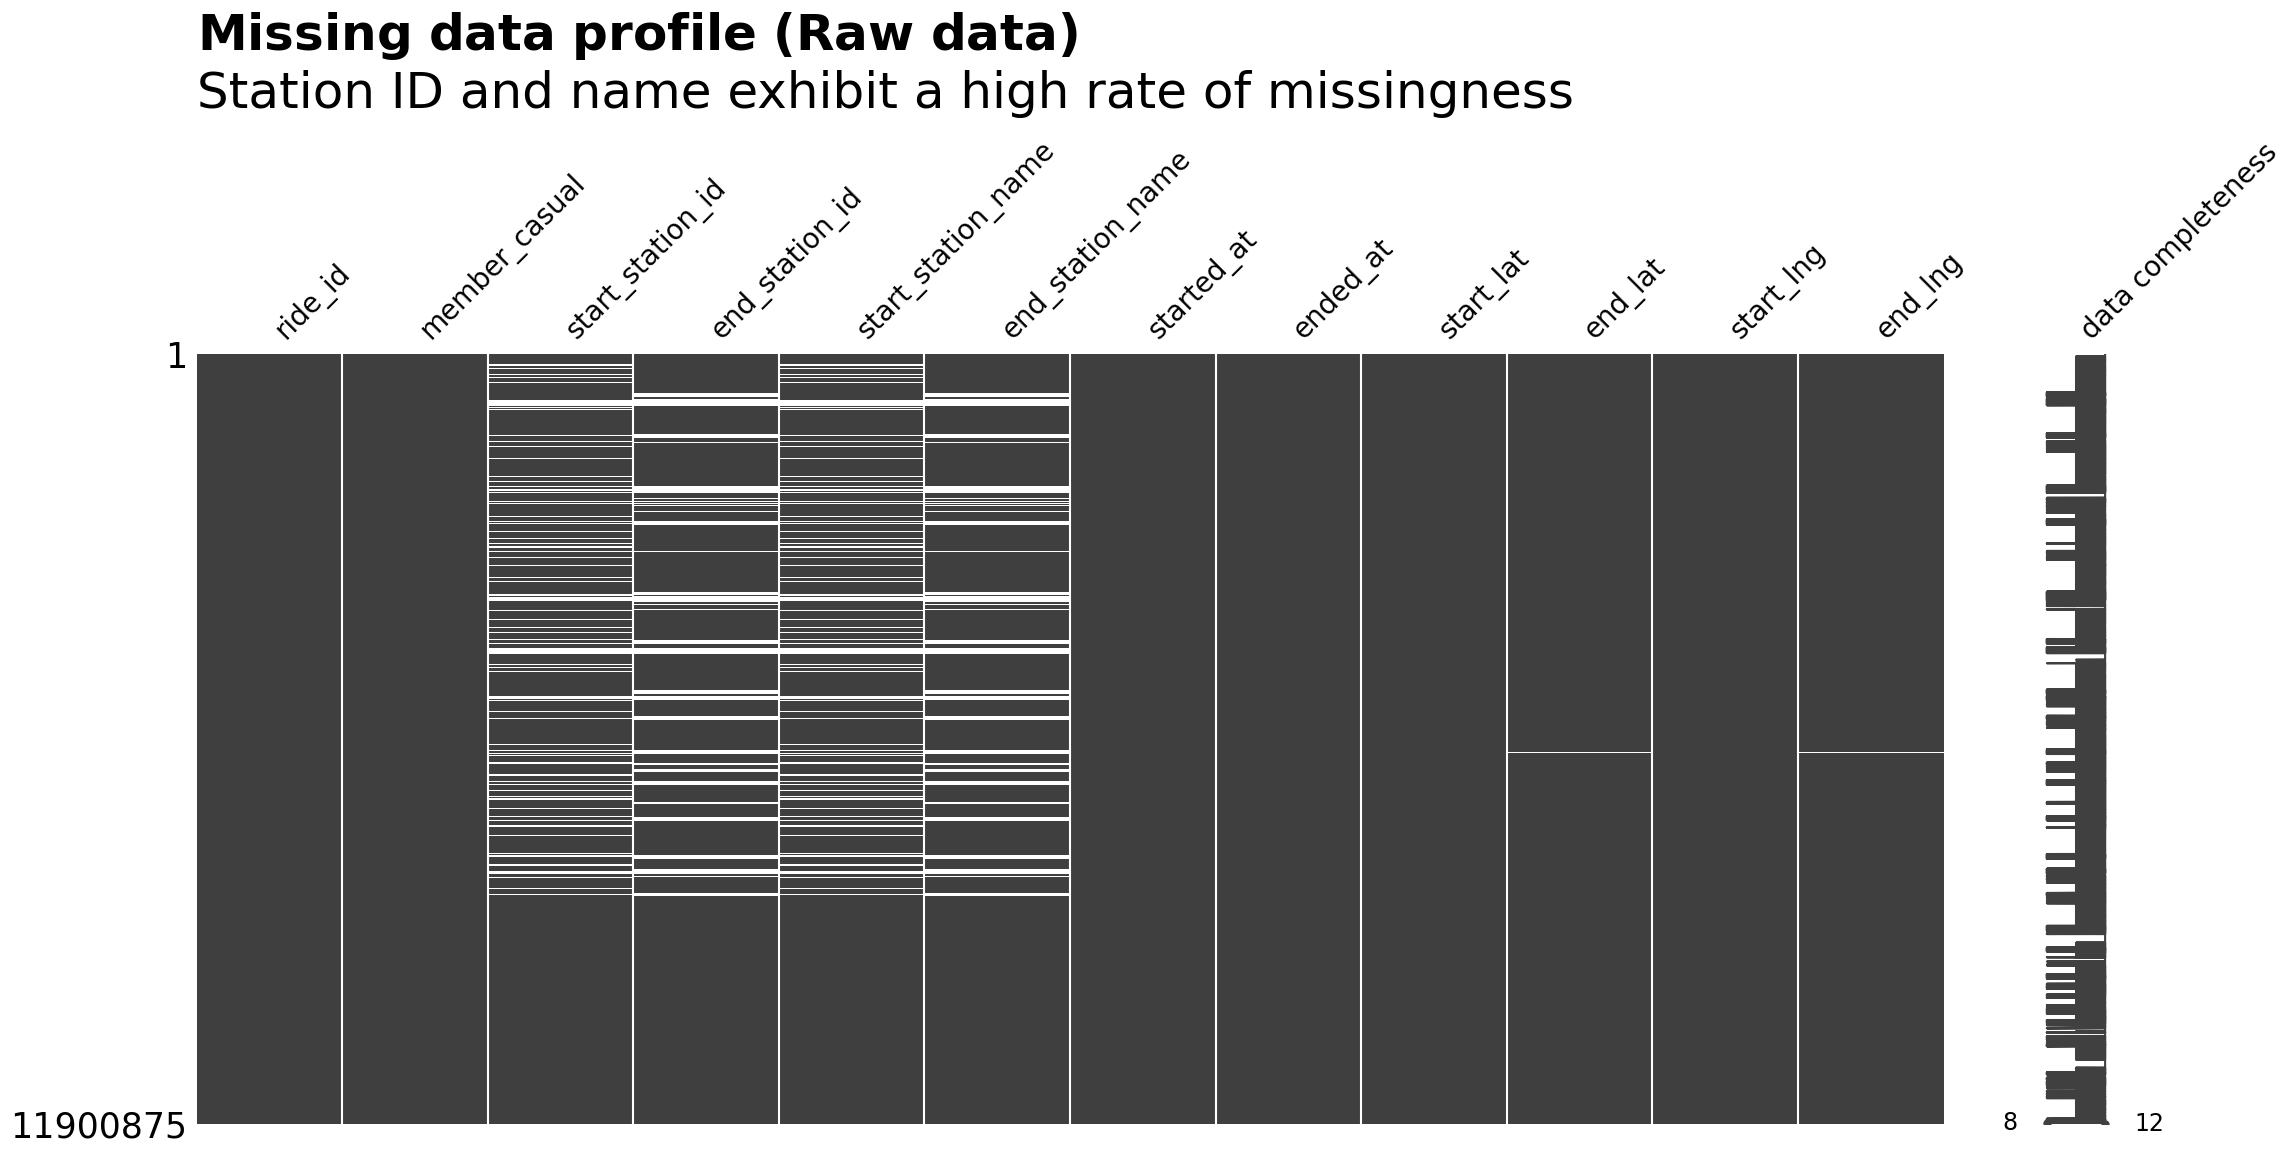

In [4]:
# Data Quality • Completeness → How does the missing data profile look like, by feature?

msno.matrix(df, labels=True, fontsize=20)

plt.title(
    r"$\bf{Missing\ data\ profile\ (Raw\ data)}$"
    "\nStation ID and name exhibit a high rate of missingness",
    fontsize=36,
    loc='left',
    pad=20
)
plt.show()

The chart above shows `(start/end)_station_id` and `(start/end)_station_name` as the variables with the highest missingness. This stems directly from operational design: dockless e-bikes can be unlocked and parked anywhere, with location fully captured by latitude and longitude. For station-based rides, missing ID and name details are resolved ahead, in the **Data Quality uniqueness** assessment, using a **canonical spatial map**.

Completeness is following evaluated considering the analytical objective of the study. Since the goal goes through constrasting the behavior of **casual riders** to that of **members**, a key requirement is that missing data do not materially distort **the relative representation of the two groups** across the variables used in the analysis.

To detect potential distortions, the **member-to-casual record ratio** time series below provides a quick visual check for unusual oscillations that could signal asymmetric completeness issues, biasing member-to-casual proportions and compromising downstream conclusions.

<p style="font-size:24px">Are the missing data biased toward a particular segment?</p>

**Summary statistics: Daily ride counts by metric and user segment &nbsp;|&nbsp; Raw data**

**Summary statistics: Daily member-to-casual ratios per metric (wide format) &nbsp;|&nbsp; Raw data**

,started_at_cnt,ended_at_cnt,start_lat_cnt,end_lat_cnt,start_lng_cnt,end_lng_cnt
count,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000
mean,2.639281,2.639281,2.639281,2.646793,2.639281,2.646793
std,1.459896,1.459896,1.459896,1.471920,1.459896,1.471920
min,0.673440,0.673440,0.673440,0.674646,0.673440,0.674646
25%,1.644268,1.644268,1.644268,1.647835,1.644268,1.647835
50%,2.179215,2.179215,2.179215,2.193170,2.179215,2.193170
75%,3.447844,3.447844,3.447844,3.471989,3.447844,3.471989
max,10.983607,10.983607,10.983607,12.092593,10.983607,12.092593


**Overall summary statistics of combined member-to-casual ratio &nbsp;|&nbsp; Raw data**

,count,mean,std,min,25%,50%,75%,max
ratio,4566.0,2.641785,1.463118,0.67344,1.644785,2.183489,3.465953,12.092593


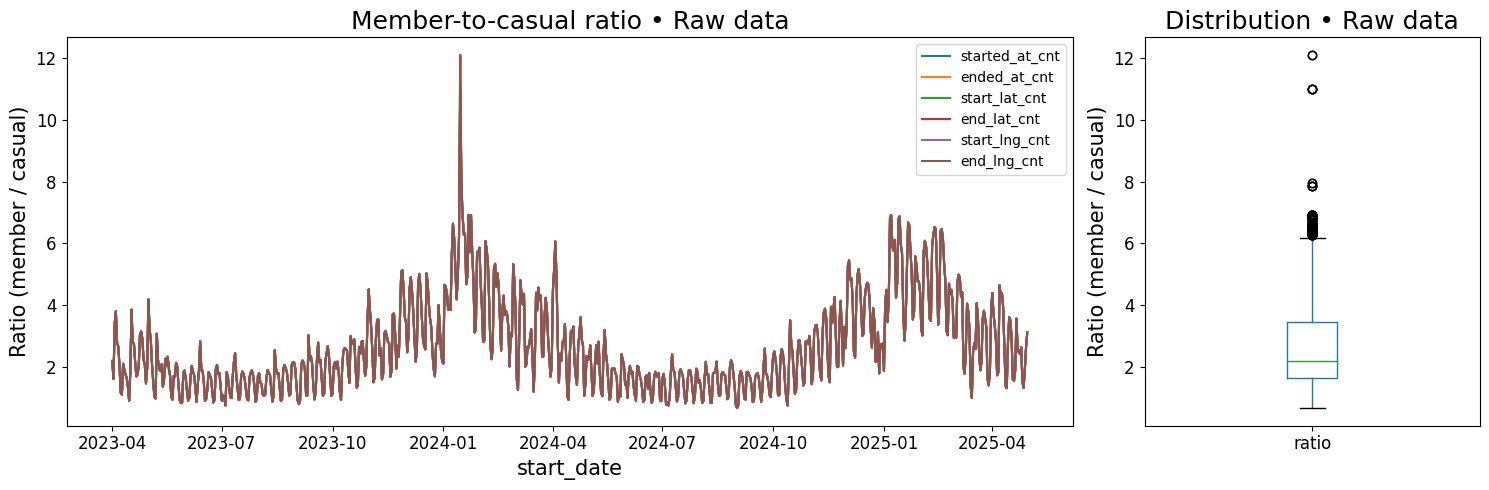

In [5]:
# Data Quality • Completeness → Are the missing data biased toward a particular segment?

display_markdown('<p style="font-size:24px">Are the missing data biased toward a particular segment?</p>', raw=True)

# ------------------------------------------------------------------------------------------------------------------------------
# 1. Get count ratio for each of the selected variables, for visual checking
# ------------------------------------------------------------------------------------------------------------------------------
# Create column for daily aggregation
df['start_date'] = df['started_at'].dt.date

# Count records for each day and `member_casual` ride type
record_count = df.groupby([df['start_date'], df['member_casual']]).agg(
    started_at_cnt = ('started_at', 'count'),
      ended_at_cnt = (  'ended_at', 'count'),
     start_lat_cnt = ( 'start_lat', 'count'),
       end_lat_cnt = (   'end_lat', 'count'),
     start_lng_cnt = ( 'start_lng', 'count'),
       end_lng_cnt = (   'end_lng', 'count')
)

# Unstack the 'member_casual' index level
unstacked_count_filled = record_count.unstack(level='member_casual').fillna(0) # fillna ensures perfect pairing
display_markdown('**Summary statistics: Daily ride counts by metric and user segment &nbsp;|&nbsp; Raw data**', raw=True)
display_fit_to_width(unstacked_count_filled.describe().astype(int))

# Create DataFrame to store calculated ratios, same index as unstacked counts (the dates)
ratio = pd.DataFrame(index=unstacked_count_filled.index)

# Calculate ratios
for count_type in unstacked_count_filled.columns.levels[0]:
    member_series = unstacked_count_filled[(count_type, 'member')]
    casual_series = unstacked_count_filled[(count_type, 'casual')]
    ratio_series  = member_series / casual_series
    # ratio[f'{count_type}_member_to_casual_ratio'] = ratio_series
    ratio[f'{count_type}'] = ratio_series
display_markdown('**Summary statistics: Daily member-to-casual ratios per metric (wide format) &nbsp;|&nbsp; Raw data**', raw=True)
display_fit_to_width(ratio.describe())

# ------------------------------------------------------------------------------------------------------------------------------
# 2. Get a sorted list of ratios, to capture discrepancies
# ------------------------------------------------------------------------------------------------------------------------------
# Unpivot ratios
ratio_long = pd.melt(
    ratio.reset_index(),
    id_vars=['start_date'],  # The column(s) to keep as identifiers
                             # value_vars is optional here, as all other columns are value columns
    var_name='count_type',   # New column name for the melted column headers
    value_name='ratio'       # New column name for the values
).set_index('start_date')

# Clean up 'count_type', and sort
ratio_long['count_type'] = ratio_long['count_type'] #.str.replace('_member_to_casual_ratio', '')
ratio_long = ratio_long.sort_values(by='ratio', ascending=False)
display_markdown('**Overall summary statistics of combined member-to-casual ratio &nbsp;|&nbsp; Raw data**', raw=True)
display(ratio_long.describe().T)

# ------------------------------------------------------------------------------------------------------------------------------
# 3. Display
# ------------------------------------------------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [9, 3]})

ratio.plot(ax=axes[0])
axes[0].set_title ('Member-to-casual ratio • Raw data', fontsize=18)
axes[0].set_ylabel('Ratio (member / casual)', fontsize=15)
axes[0].set_xlabel('start_date', fontsize=15)
axes[0].tick_params(axis='both', labelsize=12)

ratio_long.boxplot(column='ratio', ax=axes[1], grid=False)
axes[1].set_title ('Distribution • Raw data', fontsize=18)
axes[1].set_ylabel('Ratio (member / casual)', fontsize=15)
axes[1].tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

The tables and charts above help answer the following questions:
* What does the **member-to-casual ratio** look like for **each variable** over the analyzed period?
* Do these **ratios** remain **stable over time**?
* Are the **outstanding ratios** due to **operational process** or data capture issues?

<br>

From '_**Summary statistics: Daily ride counts by metric and user segment**_', we observe that there were **rides every day**, for both user segments, throughout the considered period (as min `started_at_cnt` = 61, not zero). The same summary also suggests **data loss** affecting **trip endpoint geolocation**: endpoint record counts (casual: 5,651; member: 9,968) are lower than those of the remaining variables (casual: 5,666; member: 9,971).

The pattern is even clearer in _**Summary statistics: Daily member-to-casual ratios per metric**_. **Endpoint geolocation** variables consistently exhibit higher member-to-casual ratios, indicating that **missing records disproportionately affect casual riders** rather than both groups equally. This introduces **systematic bias** due to missingness, **potentially affecting the conclusions** of this case study.

The charts reveal the temporal and distributional patterns. The time series on the left shows a **distinct peak**, representing a substantial departure from the typical member-to-casual ratio. The boxplot on the right confirms the presence of **outliers**, some of them exceeding five times the median ratio.

Taken together, the tables and charts suggest that these ratio shifts cannot be explained solely by operational variability. Because trip completion (`ended_at_cnt`) remains consistent with the other variables, the evidence points to a **decoupling** between **trip-completion** recording and **trip-endpoint geolocation** capture, resulting in **missing endpoint coordinates**.

<br>

In the next code cell, let's further inspect the issue, looking at some qualitative questions:
* What do these **outlier days** have **in common**?
* Do they occur **systematically**?

Finally, let's wrap-up the **data completeness** check by quantifying: 
* How many **days** contain at least one **outlier**?
* What **percentage of all analyzed days** do these **outliers** represent?
* What **percentage of all ratio observations** are classified as outliers?

<span style="font-size:18px">Diagnosis • Hypothesis Generation</span><br><span style="font-size:30px">What might explain the missing data?</span>

**Anomalous days:** Outliers occurred on **20 distinct days** (**2.63%**):
  * **2024-01:** 09, 14, 15, 16, 17, 18, 19, 22, 24
  * **2025-01:** 06, 07, 13, 14, 21, 22
  * **2025-02:** 11, 12, 13, 17, 18

**Monthly clustering:** Outliers were observed in only **3 year-months**  (out of total 25 observed):<br>`2024-01` • `2025-01` • `2025-02`

**Metric-level outlier coverage:** **118** metric outliers / **4,566** total metric observations (**2.58%**)

### **Dual-phenomena cause analysis**

The diagnostics reveal **two distinct phenomena** distorting the member-to-casual ratio:

To isolate the structural bias from macro operational noise, the 20 severe weather dates have been **filtered out** of the time series below:

1. **Macro operational disruption • Winter days:** Binary clustering across 20 winter dates shows a widespread distortion of ratios (118 total metric-day outliers).
2. **Persistent endpoint geolocation decoupling:** With outliers removed, the chart clearly shows that `end_lat` and `end_lng` ratios consistently sit **above 1.0** the baseline daily average (1.0), unlike start coordinates and trip completion counts. This gives evidence of a persistent, non-random loss of casual rider endpoint coordinates steadily present during normal operation.

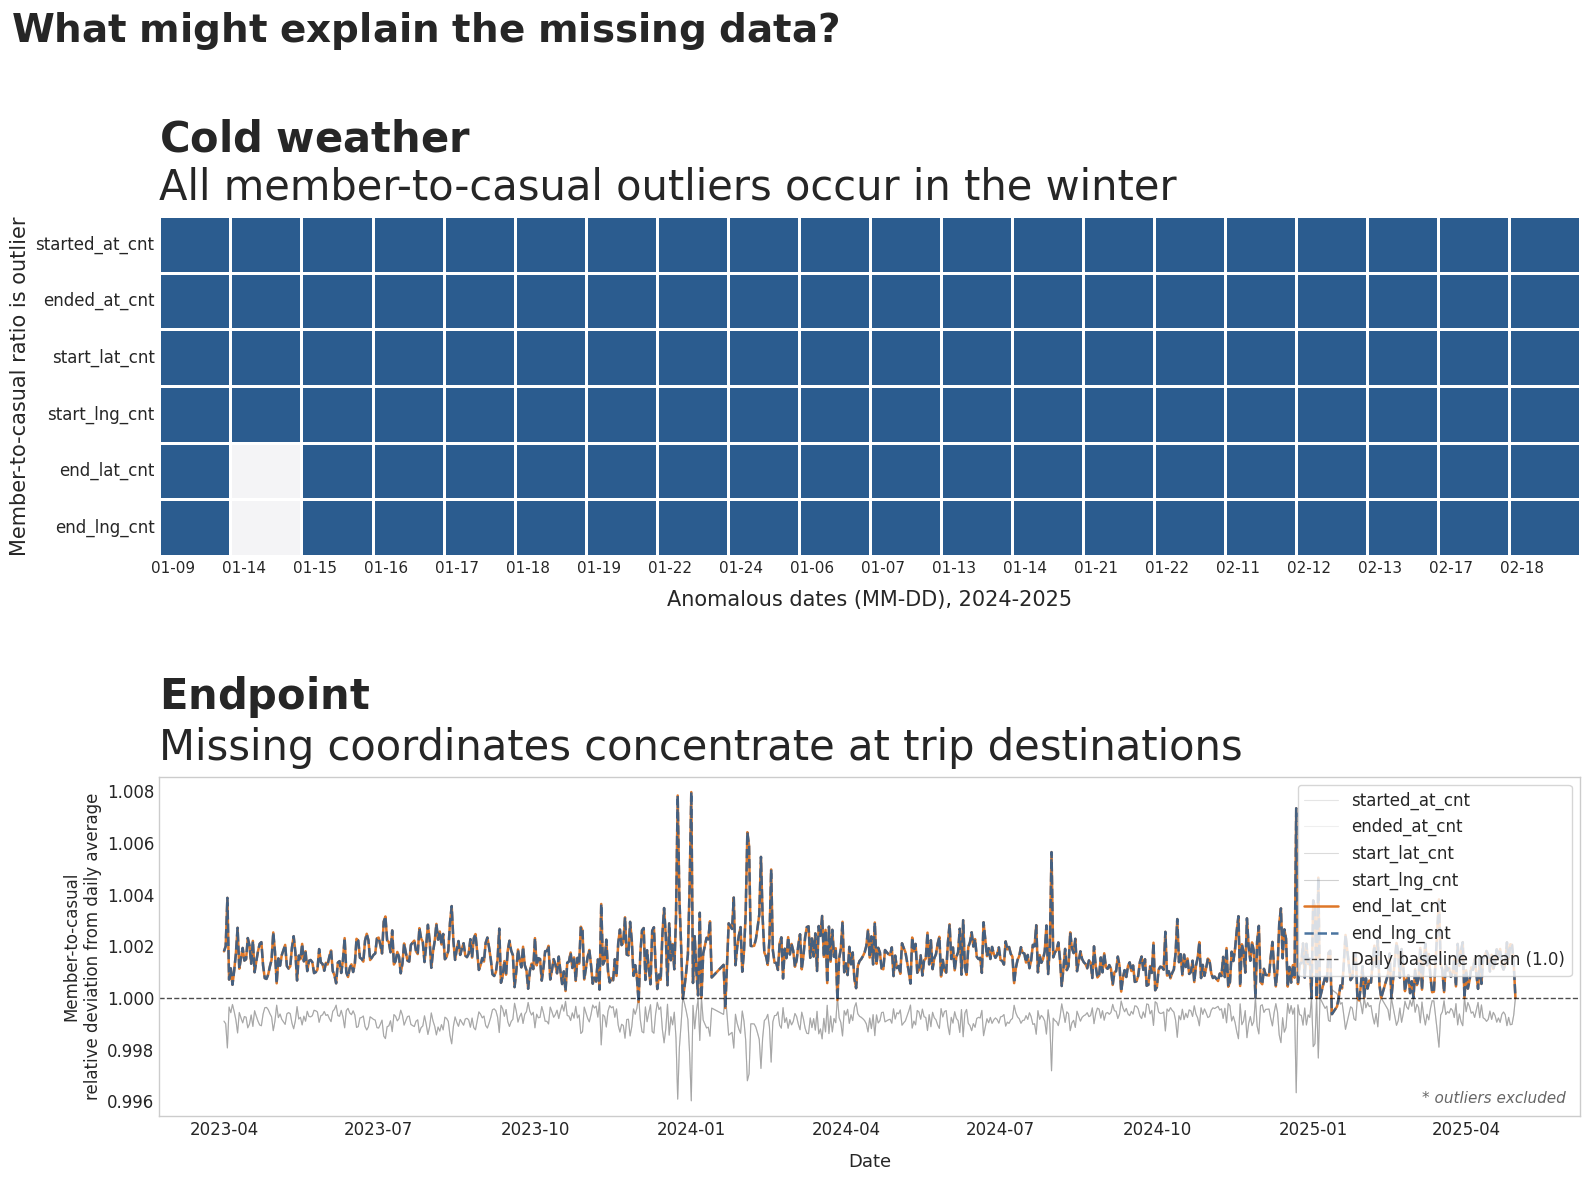

In [6]:
# Data Quality • Completeness → What might explain the missing data?

_  = '<span style="font-size:18px">Diagnosis • Hypothesis Generation</span><br>'
_ += '<span style="font-size:30px">What might explain the missing data?</span>'
display_markdown(_, raw=True)

# ------------------------------------------------------------------------------------------------------------------------------
# 1. Calculate upper and lower fences (using IQR)
# ------------------------------------------------------------------------------------------------------------------------------
quartiles = ratio_long.groupby('count_type')['ratio'].quantile([0.25, 0.75]).unstack()
quartiles.columns = ['Q1', 'Q3']
quartiles['IQR'] = quartiles['Q3'] - quartiles['Q1']
quartiles['lower_fence'] = quartiles['Q1'] - (1.5 * quartiles['IQR'])
quartiles['upper_fence'] = quartiles['Q3'] + (1.5 * quartiles['IQR'])

# ------------------------------------------------------------------------------------------------------------------------------
# 2. Identify the outlier days
# ------------------------------------------------------------------------------------------------------------------------------
ratio_with_fences = pd.merge(
    ratio_long.reset_index(),
    quartiles[['lower_fence', 'upper_fence']],
    on='count_type',
    how='left'
)

outlier_mask = (ratio_with_fences['ratio'] < ratio_with_fences['lower_fence']) | \
               (ratio_with_fences['ratio'] > ratio_with_fences['upper_fence'])

outliers_detected = ratio_with_fences[outlier_mask].sort_values(by='start_date')

# ------------------------------------------------------------------------------------------------------------------------------
# 3. Format and display summary metrics
# ------------------------------------------------------------------------------------------------------------------------------

# A. Group anomalous days by YYYY-MM
outlier_days = sorted(outliers_detected['start_date'].unique())
total_unique_days = df['start_date'].nunique()
proportion_of_days_w_outliers = len(outlier_days) / total_unique_days

grouped = defaultdict(list)
for d in sorted(outlier_days):
    grouped[str(d)[:7]].append(str(d))
# formatted_groups = '\n'.join(
#     f"  * **{month}:** {', '.join(dates[-2:])}" for month, dates in grouped.items()
# )
formatted_groups = '\n'.join(
    f"  * **{month}:** {', '.join(d[-2:] for d in dates)}" 
    for month, dates in grouped.items()
)
outlier_days_txt = (
    f"**Anomalous days:** Outliers occurred on **{len(outlier_days)} distinct days** "
    f"(**{proportion_of_days_w_outliers:.2%}**):\n{formatted_groups}"
)
display_markdown(outlier_days_txt, raw=True)

# B. Monthly clustering
unique_ym_count = pd.to_datetime(df['start_date']).dt.to_period('M').nunique()
outlier_ym = sorted(grouped.keys())

outlier_ym_text = (
    f"**Monthly clustering:** Outliers were observed in only **{len(outlier_ym)} year-months** "
    f" (out of total {unique_ym_count} observed):<br>" + " • ".join(f"`{ym}`" for ym in outlier_ym)
)
display_markdown(outlier_ym_text, raw=True)

# C. Metric-level observation coverage
selected_var_record_cnt  = len(ratio_long)
selected_var_outlier_cnt = len(outliers_detected)
proportion_of_records_w_outliers = selected_var_outlier_cnt / selected_var_record_cnt

obs_txt = (
    f"**Metric-level outlier coverage:** **{selected_var_outlier_cnt:,}** metric outliers / "
    f"**{selected_var_record_cnt:,}** total metric observations (**{proportion_of_records_w_outliers:.2%}**)"
)
display_markdown(obs_txt, raw=True)

# ------------------------------------------------------------------------------------------------------------------------------
# 4. Narrative text
# ------------------------------------------------------------------------------------------------------------------------------
analysis_txt = (
    "### **Dual-phenomena cause analysis**\n\n"    
    "The diagnostics reveal **two distinct phenomena** distorting the member-to-casual ratio:\n\n"
    "To isolate the structural bias from macro operational noise, "
    "the 20 severe weather dates have been **filtered out** of the time series below:\n\n"
    "1. **Macro operational disruption • Winter days:"
    "** Binary clustering across 20 winter dates shows a widespread distortion of ratios "
    "(118 total metric-day outliers).\n"
    "2. **Persistent endpoint geolocation decoupling:** With outliers removed, "
    "the chart clearly shows that `end_lat` and `end_lng` ratios "
    "consistently sit **above 1.0** the baseline daily average (1.0), unlike start coordinates and trip completion counts. "
    "This gives evidence of a persistent, non-random loss of casual rider "
    "endpoint coordinates steadily present during normal operation."
)

display_markdown(analysis_txt, raw=True)

# ------------------------------------------------------------------------------------------------------------------------------
# 5. Derive ratio_wide from unstacked_count_filled
# ------------------------------------------------------------------------------------------------------------------------------
metrics = ['started_at_cnt', 'ended_at_cnt', 'start_lat_cnt', 'start_lng_cnt', 'end_lat_cnt', 'end_lng_cnt']
ratio_wide = pd.DataFrame(index=unstacked_count_filled.index)

for col in metrics:
    casual = unstacked_count_filled[(col, 'casual')]
    member = unstacked_count_filled[(col, 'member')]
    ratio_wide[col] = member / casual.replace(0, np.nan)

# ------------------------------------------------------------------------------------------------------------------------------
# 6. Data prep for visuals
# ------------------------------------------------------------------------------------------------------------------------------
# A. Binary Heatmap Matrix (Left Plot - Keeps all 20 outlier days)
heatmap_data = outliers_detected.pivot(index='count_type', columns='start_date', values='ratio')
heatmap_binary = heatmap_data.notna().astype(int)

# B. Relative Ratio Matrix (Right Plot - EXCLUDES outlier_days)
clean_ratio_wide = ratio_wide[~ratio_wide.index.isin(outlier_days)]

daily_mean_ratio = clean_ratio_wide.mean(axis=1)
relative_ratios = clean_ratio_wide.divide(daily_mean_ratio, axis=0)

# Sort metrics for consistent visual order
metric_order = ['started_at_cnt', 'ended_at_cnt', 'start_lat_cnt', 'start_lng_cnt', 'end_lat_cnt', 'end_lng_cnt']
heatmap_binary  =  heatmap_binary.reindex(        [m for m in metric_order if m in heatmap_binary.index])
relative_ratios = relative_ratios.reindex(columns=[m for m in metric_order if m in relative_ratios.columns])

date_labels = [str(d)[5:] for d in heatmap_binary.columns]

# ------------------------------------------------------------------------------------------------------------------------------
# 7. Plot
# ------------------------------------------------------------------------------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# --- MAIN TITLE ---
fig.suptitle(
    r"$\bf{What\ might\ explain\ the\ missing\ data?}$",
    fontsize=28,
    x=0.01,
    ha='left',
    y=0.98
)

# --- TOP CHART ---
cmap = sns.color_palette(["#f4f4f6", "#2b5c8f"])
sns.heatmap(
    heatmap_binary,
    ax=axes[0],
    cmap=cmap,
    cbar=False,
    linewidths=1,
    linecolor='white'
)

axes[0].set_title(
    r"$\bf{Cold\ weather}$"
    "\nAll member-to-casual outliers occur in the winter",
    fontsize=30, pad=12, loc='left'
)
axes[0].set_xlabel('Anomalous dates (MM-DD), 2024-2025', fontsize=15, labelpad=10)
axes[0].set_ylabel('Member-to-casual ratio is outlier', fontsize=15)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].set_xticklabels(date_labels, rotation=0, ha='right', fontsize=11)

# --- BOTTOM CHART ---
line_styles = {
    'end_lat_cnt': '-',
    'end_lng_cnt': '--'
}

colors = {
    'started_at_cnt': '#aaaaaa',
      'ended_at_cnt': '#cccccc',
     'start_lat_cnt': '#888888',
     'start_lng_cnt': '#666666',
       'end_lat_cnt': '#d95f02',
       'end_lng_cnt': '#2b5c8f',
}

for col in relative_ratios.columns:
    is_endpoint = 'end_' in col and 'cnt' in col
    alpha     = 0.85 if is_endpoint else 0.30
    linewidth = 1.8  if is_endpoint else 0.8
    linestyle = line_styles.get(col, '-')
    
    axes[1].plot(
        relative_ratios.index, 
        relative_ratios[col], 
        label=col, 
        color=colors.get(col, '#333333'), 
        alpha=alpha, 
        linewidth=linewidth,
        linestyle=linestyle
    )

axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Daily baseline mean (1.0)')
axes[1].set_title(
    r"$\bf{Endpoint}$"
    "\nMissing coordinates concentrate at trip destinations",
    fontsize=30, pad=12, loc='left'
)
axes[1].set_xlabel('Date', fontsize=13, labelpad=10)
axes[1].set_ylabel('Member-to-casual\nrelative deviation from daily average', fontsize=12)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].legend(loc='upper right', fontsize=12, frameon=True)
axes[1].grid(False)

axes[1].text(
    0.99, 0.03,
    "* outliers excluded", 
    fontsize=11, 
    fontstyle='italic', 
    color='#666666', 
    ha='right',
    va='bottom', 
    transform=axes[1].transAxes
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.65)
plt.show()

From the results above, we conclude that:
* The distribution of daily record counts is **similar across the selected variables**.
* The distributions of ratios are similar across most variables, with a **distinct pattern** observed for **endpoint geolocation**.
* The **differing ratios** do not appear to be solely justifiable by the operational process itself, as `ended_at_cnt` (count of  date and time when a trip ended) aligns with other variables. This discrepancy points to a **data loss** affecting endpoint geolocation.
* We notice that the outlier days occurred in **January** and **February** (a pattern further explored below).
* The **anomalies exhibit temporal clustering** (based on two years of observations), with **casual riders' percentage notably decreasing in Jan and Feb**.

Finally, regarding our approach to these days:
* A total of 20 days was identified as presenting an abnormally high member-to-casual ratio.
* Out of an overall total of 761 days being considered, these represent about **2.6% of the days**.
* In terms of **individual ratio observations** identified as outliers, this represents 118 observations out of a total of 4,566 analyzed, also about **2.6%**.

#### Handling the outliers  
Considering our **goal** of getting a **grasp on the major trends** in Cyclistic bike **usage behavior of members versus casual users**, let's **drop the outlier days**, as well as days **lacking records for any of the selected variables** (except station names, for the reason mentioned before). 

In addition to the quantitative treatment, let's **take notice** of how the **member-to-casual ratio** varies **along the year**. In seeking for root causes for geolocation data loss in January and February in Chicago, a qualitative discussion is presented below.

---

From [Google Search AI Overview](http://google.com/) on **«&nbsp;what's special in chicago in Jan Feb&nbsp;»**:  
> Chicago in January and February offers a unique blend of **winter activities** and **indoor attractions**. _Choose Chicago_ suggests that winter brings opportunities for ice skating at Chicago Park District, exploring winter gardens, and enjoying live theater or comedy. The city also boasts festivals like _Tomorrow Never Knows_ and _The Morton Arboretum's_ holiday light displays.
> > Key aspects of Chicago in January and February:  
> > **Cold Weather**: **January is the coldest month**, with average temperatures around 30°F (-1°C), and February also sees very chilly weather.
> **Indoor Activities**: Many attractions like museums, art galleries, and theaters offer a welcome escape from the cold.
> **Outdoor Fun**: Ice skating at Millennium Park and Maggie Daley Park, and even rooftop curling, are popular winter activities.
> > **Festivals and Events**: The city hosts various events and festivals, including indie music and comedy at Tomorrow Never Knows and the Winter Flower Show.
> > **Holiday Lights**: The Morton Arboretum, the Garfield Park Conservatory offers a Winter Flower Show.
> > **Sports**: You can cheer for the Chicago Bears, Bulls, or Blackhawks during the winter months.
> > 
> In summary, Chicago's winter offers a mix of fun in the **snow** and **indoor attractions**, making it a worthwhile destination even in the colder months.

 ---

By [Gemini 2.5 Flash](https://gemini.google.com/), on factors potentially causing **data loss** for the **endpoint geolocation**:

**«&nbsp;How cold weather could cause data loss&nbsp;»**  
* **Sensor/GPS Malfunction**: Extreme cold can affect the performance of GPS units, battery life, or other sensors on the bikes or docking stations, leading to patchy or failed location data recordings.  
* **User Behavior in Cold**: Casual riders might be less inclined to properly dock or end a ride if they are rushing to get indoors, or if the docking mechanism itself is frozen/malfunctioning, leading to incomplete transaction data. Or perhaps the bikes are left in places where GPS signal is weaker (e.g., covered areas to avoid snow).  
* **Operational Changes**: It's also possible (though less likely for "loss") that operations change slightly in winter (e.g., staff less frequently checking stations, different maintenance procedures) that could indirectly impact data collection fidelity.

**«&nbsp;What could cause data loss biased towards the end-of-journey geolocation?&nbsp;»**  
* **Battery Drain & Cold Impact**: GPS modules and data transmitters consume power. As a ride progresses, the bike's battery drains. Cold weather significantly reduces battery efficiency and capacity. By the end of a longer ride in freezing temperatures, the battery might be critically low, causing the GPS unit or the data transmission module to fail or operate unreliably, leading to a missed final location ping.  
* **Docking Station Environment & Signal Issues**: Docking stations are often located in specific urban environments. If these stations are in areas with poor GPS signal reception (e.g., under large structures, within dense urban canyons, or even inside covered/sheltered areas to avoid snow), the bike might lose its precise location signal just as it's being returned. The system might rely on the bike itself to send the final GPS coordinates upon successful docking. If the GPS is weak at that precise moment, the timestamp of the ride ending might be recorded by the station's internal clock or network, but the coordinates are lost.  
* **User Behavior (Especially in Cold/Rush)**: _**Expedited Docking**_: In cold weather, users, especially casual riders, might be eager to get indoors quickly. They might hastily dock the bike without ensuring it's fully locked and registered, potentially interrupting a final data transmission. _**App Interaction**_: If ending a ride also involves an app interaction that requires a stable network or GPS signal, a user rushing the process in cold conditions might fail to complete that step robustly, leading to incomplete end-of-trip data.  
* **System Design & Redundancy**: It's possible the system has different redundancies for start vs. end locations. A start location is critical for unlocking a bike, so there might be more robust mechanisms (e.g., cell tower triangulation, Wi-Fi triangulation, multiple GPS pings) to ensure that first location is always recorded accurately. End locations might have less stringent requirements or rely on a single, more fallible method.

---

The observed **increase in missing endpoint geolocation for casual riders**, together with the hypothetical causes for it (including behavior that could increase operational costs, for example, by 'rescuing lost bicycles' in more frequent dead spots by casuals than for members), is **consistent with the Finance team's finding** that show **members** as not only bringing more revenue, but as being also **more _profitable_**.

<p style="font-size:24px">Data Quality • Completeness → Cleanup</p>

**Missing values • Raw data**

,Missing values count,Missing values percentage
ride_id,0,0.00
member_casual,0,0.00
start_station_id,2036853,17.12
end_station_id,2123700,17.84
start_station_name,2036853,17.12
end_station_name,2123700,17.84
started_at,0,0.00
ended_at,0,0.00
start_lat,0,0.00
end_lat,14404,0.12


**Raw data record count**: 11,900,875 records

**Record count after data completeness clean-up for member-to-casual record count ratio outlier days**: 11,835,073 records

...

**Summary statistics: Daily ride counts by metric and user segment &nbsp;|&nbsp; Cleaned data**

**Summary statistics: Daily member-to-casual ratios per metric (wide format) &nbsp;|&nbsp; Cleaned data**

,started_at_cnt,ended_at_cnt,start_lat_cnt,start_lng_cnt,end_lat_cnt,end_lng_cnt
count,741.000000,741.000000,741.000000,741.000000,741.000000,741.000000
mean,2.530566,2.530566,2.530566,2.530566,2.530566,2.530566
std,1.291867,1.291867,1.291867,1.291867,1.291867,1.291867
min,0.674646,0.674646,0.674646,0.674646,0.674646,0.674646
25%,1.629966,1.629966,1.629966,1.629966,1.629966,1.629966
50%,2.160026,2.160026,2.160026,2.160026,2.160026,2.160026
75%,3.300207,3.300207,3.300207,3.300207,3.300207,3.300207
max,6.169553,6.169553,6.169553,6.169553,6.169553,6.169553


**Overall summary statistics of combined member-to-casual ratios &nbsp;|&nbsp; Cleaned data**

,count,mean,std,min,25%,50%,75%,max
ratio,4446.0,2.530566,1.29114,0.674646,1.629966,2.160026,3.300207,6.169553


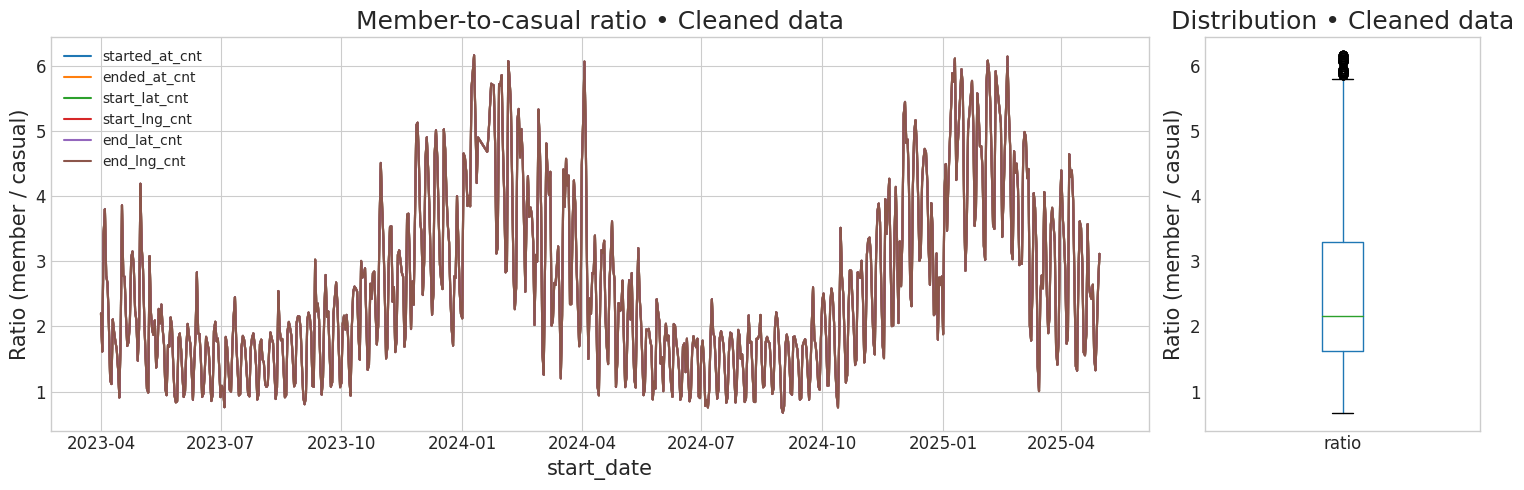

In [7]:
# Data Quality • Completeness → Cleanup

display_markdown('<p style="font-size:24px">Data Quality • Completeness → Cleanup</p>', raw=True)

# Calculate NA count and percentage
na_count      = df.isna().sum().astype(int)
na_percentage = (100 * df.isna().sum() / len(df)).round(2)

# Create the summary DataFrame
na_summary_df = pd.DataFrame({
    'Missing values count'     : na_count,
    'Missing values percentage': na_percentage
})

# Display the result
display_markdown('**Missing values • Raw data**', raw=True)
display(na_summary_df)

# Keep track of the original record count
record_count_0_original = len(df)
display_markdown(f'**Raw data record count**: {record_count_0_original:,} records', raw=True)

# Drop outlier days
df = df[df['start_date'].isin(outlier_days)==False]

# Keep track of the updated record count
record_count_1_completeness_oulier_days = len(df)
display_markdown(f'**Record count after data completeness clean-up for member-to-casual record count ratio outlier days**: {record_count_1_completeness_oulier_days:,} records', raw=True)

# Drop records with missing values for the selected variables
selected_columns = ['started_at', 
                    'ended_at',
                    'start_lat',
                    'start_lng',
                    'end_lat',
                    'end_lng']
df = df.dropna(subset=selected_columns)

# Keep track of the updated record count
record_count_2_completeness_selected_var_na = len(df)
display_markdown(f'**Record count after data completeness clean-up for missing values of selected variables**: {record_count_2_completeness_selected_var_na:,} records', raw=True)

# Calculate NA count and percentage
na_count      = df.isna().sum().astype(int)
na_percentage = (100 * df.isna().sum() / len(df)).round(2)

# Create the summary DataFrame
na_summary_df = pd.DataFrame({
    'Missing values count'     : na_count,
    'Missing values percentage': na_percentage
})

# Display the result
display_markdown('**Missing values • Cleaned data**', raw=True)
display(na_summary_df)


# ------------------------------------------------------------------------------------------------------------------------------
# 1. Get count ratio for each of the selected variables, for visual checking
# ------------------------------------------------------------------------------------------------------------------------------
# Create column for daily aggregation
df['start_date'] = df['started_at'].dt.date

# Count records for each day and `member_casual` ride type
record_counts = df.groupby([df['start_date'], df['member_casual']]).agg(
    started_at_cnt = ('started_at', 'count'),
      ended_at_cnt = (  'ended_at', 'count'),
     start_lat_cnt = ( 'start_lat', 'count'),
     start_lng_cnt = ( 'start_lng', 'count'),
       end_lat_cnt = (   'end_lat', 'count'),
       end_lng_cnt = (   'end_lng', 'count')
)

# Unstack the 'member_casual' index level
unstacked_counts_filled = record_counts.unstack(level='member_casual').fillna(0) # fillna ensures perfect pairs
display_markdown('**Summary statistics: Daily ride counts by metric and user segment &nbsp;|&nbsp; Cleaned data**', raw=True)
display_fit_to_width(unstacked_counts_filled.describe().astype(int))

# Create DataFrame to store calculated ratios, same index as unstacked counts (the dates)
ratios = pd.DataFrame(index=unstacked_counts_filled.index)

# Calculate ratios
for count_type in unstacked_counts_filled.columns.levels[0]:
    member_series = unstacked_counts_filled[(count_type, 'member')]
    casual_series = unstacked_counts_filled[(count_type, 'casual')]
    ratio_series  = member_series / casual_series
    # ratios[f'{count_type}_member_to_casual_ratio'] = ratio_series
    ratios[f'{count_type}'] = ratio_series
display_markdown('**Summary statistics: Daily member-to-casual ratios per metric (wide format) &nbsp;|&nbsp; Cleaned data**', raw=True)
display_fit_to_width(ratios.describe())

# ------------------------------------------------------------------------------------------------------------------------------
# 2. Get a sorted list of ratios, to capture discrepancies
# ------------------------------------------------------------------------------------------------------------------------------
# Unpivot ratios
ratios_long = pd.melt(
    ratios.reset_index(),
    id_vars=['start_date'],  # The column(s) to keep as identifiers
                             # value_vars is optional here, as all other columns are value columns
    var_name='count_type',   # New column name for the melted column headers
    value_name='ratio'       # New column name for the values
).set_index('start_date')

# Clean up 'count_type', and sort
ratios_long['count_type'] = ratios_long['count_type'] #.str.replace('_member_to_casual_ratio', '')
ratios_long = ratios_long.sort_values(by='ratio', ascending=False)
display_markdown('**Overall summary statistics of combined member-to-casual ratios &nbsp;|&nbsp; Cleaned data**', raw=True)
display(ratios_long.describe().T)

# ------------------------------------------------------------------------------------------------------------------------------
# 3. Display graphically
# ------------------------------------------------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [12, 3]})

ratios.plot(ax=axes[0])
axes[0].set_title ('Member-to-casual ratio • Cleaned data', fontsize=18)
axes[0].set_ylabel('Ratio (member / casual)', fontsize=15)
axes[0].set_xlabel('start_date', fontsize=15)
axes[0].tick_params(axis='both', labelsize=12)

ratios_long.boxplot(column='ratio', ax=axes[1], grid=False)
axes[1].set_title ('Distribution • Cleaned data', fontsize=18)
axes[1].set_ylabel('Ratio (member / casual)', fontsize=15)
axes[1].tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

Final check on completeness:
* Missing values now only occur where expected by design: `station_name`, `station_id`.
* '_**Summary statistics: Daily ride counts by metric and user segment**_' now shows the **exact same count** for each metric and user segment.
* '_**Summary statistics: Daily member-to-casual ratios per metric (wide format)**_' now shows the **exact same ratio** for each metric and user.
* The **member-to-casual ratio** time series now follows expected seasonal fluctuations.
* The **outliers** shown on the boxplot now lie **quite close** to the upper fence limit.

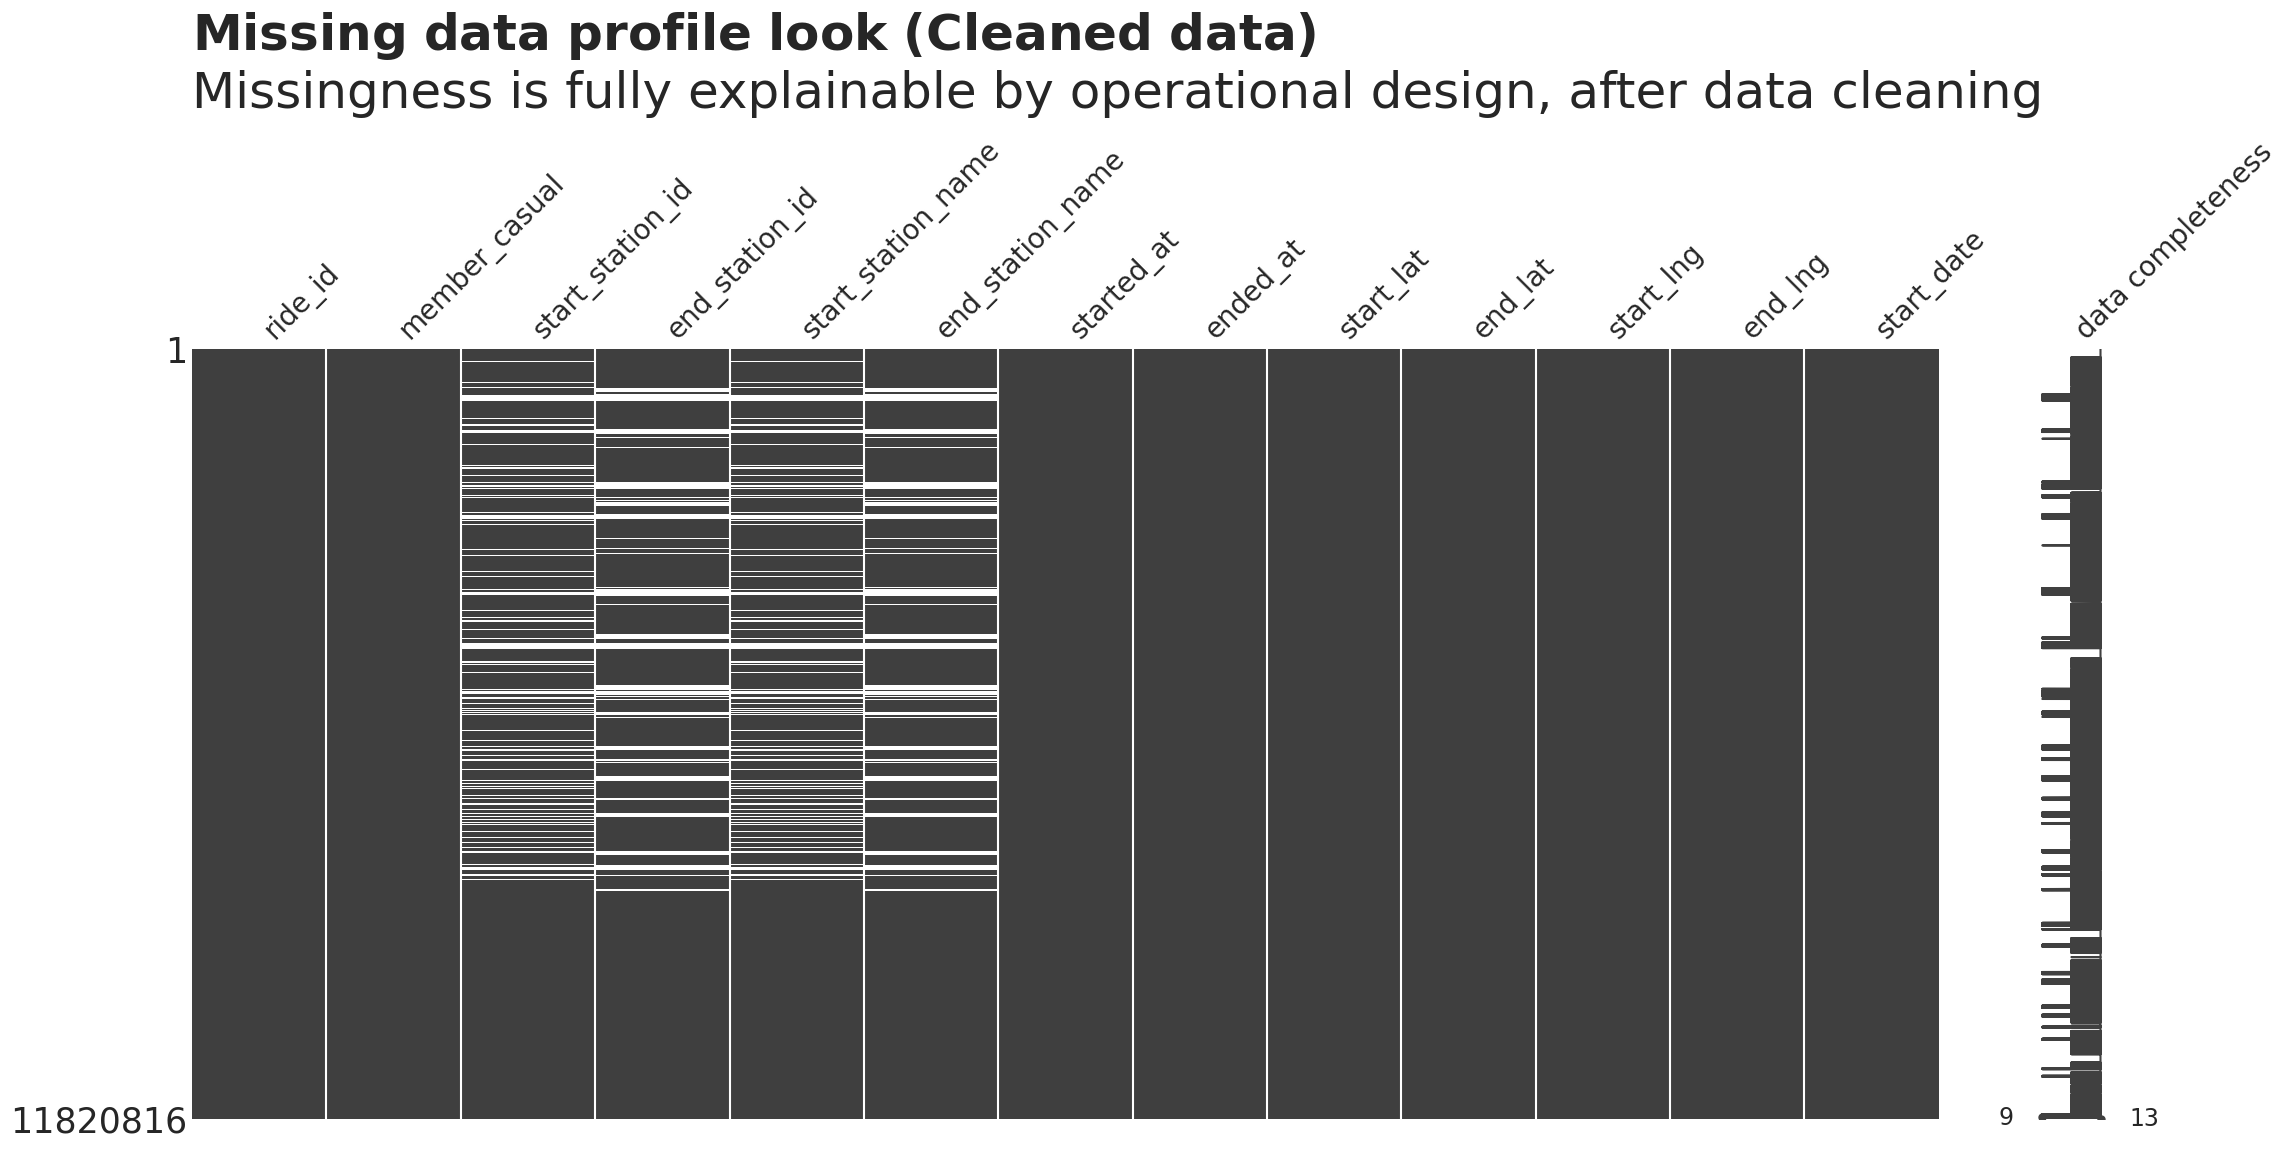

In [8]:
# Data Quality • Completeness → Cleaned data

msno.matrix(df, labels=True, fontsize=20)

plt.title(
    r"$\bf{Missing\ data\ profile\ look\ (Cleaned\ data)}$"
    "\nMissingness is fully explainable by operational design, after data cleaning",
    fontsize=36,
    loc='left',
    pad=20
)
plt.show()

#### **✓** **C**ompleteness: checked.

<br>

[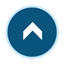](#contents)

### Uniqueness

In the context of Data Quality, **Uniqueness** is defined as follows [🔗](https://www.dama-nl.org/wp-content/uploads/2020/09/DDQ-Dimensions-of-Data-Quality-Research-Paper-version-1.2-d.d.-3-Sept-2020.pdf):

> The degree to which records occur only once in a data file.

Let's take a look again at the variables concerned in this study.

In [9]:
# Data Quality • Uniqueness → Data fields in the project

display_markdown('**Data fields in the project**', raw=True)
list(df.columns)

**Data fields in the project**

['ride_id',
 'member_casual',
 'start_station_id',
 'end_station_id',
 'start_station_name',
 'end_station_name',
 'started_at',
 'ended_at',
 'start_lat',
 'end_lat',
 'start_lng',
 'end_lng',
 'start_date']

From the list, we observe that most columns are expected to contain possible coincident or repeated values (e.g., multiple rides starting at the same time or location). The sole exception is the `ride_id`, which, as per the [dataset](https://www.kaggle.com/datasets/isissantoscosta/divvy-tripdata/) documentation, should uniquely identify **one record per ride**.  

The dataset further mentions a preparation step. The corresponding notebook shows that the original data, made monthly available, stores rides spanning two months in the files for them both (e.g. a ride started on May 31, ended on June 1st gets reported in both the May and June files). Therefore, a [deduplication step](https://www.kaggle.com/code/isissantoscosta/combine-csv-files?scriptVersionId=240721478&cellId=10) was performed during that initial preparation to ensure each ride is represented exactly once.

In the next cell, we'll verify for **`ride_id` uniqueness** by displaying:
* Total records
* Unique `ride_id`
* Total duplicated rows

In [10]:
# Data Quality • Uniqueness → Simple uniqueness (`ride_id`)

display_markdown(
    "**Ride ID Uniqueness**<br>"
    f"**Total records**: {len(df):,}<br>"
    f"**Unique `ride_id`**: {df['ride_id'].nunique():,}<br>"
    f"**Total duplicated rows**: {df.duplicated().sum():,}",
    raw=True
)

**Ride ID Uniqueness**<br>**Total records**: 11,820,816<br>**Unique `ride_id`**: 11,820,816<br>**Total duplicated rows**: 0

<a id='canonicalization'></a>

**Station Uniqueness • Canonical entity mapping**

Beyond uniqueness of individual fields, certain **combinations of fields** may also be expected to be unique, by what is called **composite uniqueness**. This is the case for Cyclistic's stations. Each `(start/end_)station_id` is expected to correspond to exactly one `(start/end_)station_name` (except for legitimate name updates) and one `(start/end)_(lat/lng)` pair. On the same reasoning, each set of `(start/end_)station_name` and `(start/end)_(lat/lng)` must map to a single `(start/end_)station_id`.  

In an ideal state, each station identifier maintains a **one-to-one** relationship with its attributes: every `(start/end_)station_id` maps to exactly one name and one coordinate pair, and vice versa. Data quality issues arise when these relationships become one-to-many, or many-to-many, and must be addressed. In dimensional modeling and data governance, managing evolution of dimension values over time is known as handling **Slowly Changing Dimensions (SCD)**. Considering that the focus of this study is the customer experience, and that stations serve the purpose of revealing customer interests, Kimball SCD technique **Type 1 (Overwrite)** [🔗](https://www.kimballgroup.com/2008/08/slowly-changing-dimensions/) will be adopted. This approach simplifies the dimension by updating and standardizing earlier `(start/end_)station_name` values into a single, current canonical form, treating multiple name versions over time as a data quality issue, rather than meaningful business signal.      

The following **data transformation** is applied to ensure **composite uniqueness** of station data:
  
* **⓵ Canonicalize station IDs**:  
  If multiple `(start/end)_station_id`s are associated with a single `(start/end_)station_name`, they are replaced by the most recent `(start/end)_station_id`. This reflects the assumption that an ID change represents a permanent change in identifier convention.

* **⓶ Canonicalize station names**:  
  In case multiple `(start/end_)station_name`s are found for a single `(start/end)_station_id`, the canonical station name is defined as the _mode_ calculated on the most recent 20% dates of the `(start/end_)station_name` time series. This approach does the following: Assumes that recent data reflects current naming conventions, keeps a buffer around potential temporary names, and covers for sparse data by not taking records too far in the history into account. In cases of tied mode values, the alphabetically first value is selected for consistency.

* **⓷ Canonicalize station coordinates**:  
  In ensuring a single association between each station and its coordinates, it must be taken into account that GPS coordinates are continuous and may contain noise, resulting in that a mode is unlikely to provide a meaningful canonical value. The _median_ value calculated on the most recent 20% dates of the `(start/end)_(lat/lng)` is therefore defined as the canonical coordinate for the station. As for names, recent data is taken given to the fact that the location of stations may be updated too. Note: In production, due to precision, the median of coordinates may be unstable and change at every data load. Spatial analytics strategies, such as [geohashing](https://www.pubnub.com/guides/what-is-geohashing/) or the [H3 grid system](https://www.uber.com/us/en/blog/h3/), make it possible to work with areas rather than points. In any case, a stabilizing approach is to anchor and lock a [golden record](https://en.wikipedia.org/wiki/Golden_record_(informatics)), by defining a distance threshold within which no update is applied (e.g., a 15 m radius).

* **➃ Exception (free-floating locations)**:  
  In the case of only `(start/end)_station_(NULL id & NULL name)` recorded for a specific `(start/end)_(lat/lng)`, this is expected for electric bicycles not picked up from / dropped off at a proper station, yet staying stationary at free-floating locations, but can also be the case of missing data at station-based rides. In eiother case, these records to not feature in the station dimension table, `dim_station`, built in the [🗲 Dimensional Modeling](#dimensional_modeling) section ahead.

The final outcome of these transformations is a canonical station lookup table, as a robust foundation for dimensional modeling, ensuring reliable joins and accurate location analytics.  

---

**Slowly Changing Dimensions (SCD) • Techniques** [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/books/data-warehouse-dw-toolkit/)

* Type 0 • Retain original
* **Type 1 • Overwrite**
* Type 2 • Add new row
* Type 3 • Add new attribute
* Type 4 • Add mini-dimension
* Type 5 • Add mini-dimension and Type 1 outrigger
* Type 6 • Add Type 1 attributes to Type 2 dimension
* Type 7 • Dual Type 1 and Type 2 dimensions

**More on Slowly Changing Dimensions (SCD):**
* Full discussion, Types 0 to 7: Kimball & Ross, _The Data Warehouse Toolkit_, 3rd ed, pp. 53-56. [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/books/data-warehouse-dw-toolkit/)
* Type 1 • Overwrite: [Kimball Group • Slowly Changing Dimensions (SCD)](https://www.kimballgroup.com/2008/08/slowly-changing-dimensions/)

---

<a id='modular_design'></a>

**Modular Design**

The canonical station lookup table—mapping station records to their canonical `station_id`, `station_name`, and coordinates—is built using a modular pipeline design. Specifically, [dbt • Data Build Tool](https://www.getdbt.com/) is adopted as the framework. Modular data pipelines improve **maintainability**, **scalability**, and **reuse** by decomposing transformations into independent components. dbt operationalizes this philosophy through **layered models** connected by a **Directed Acyclic Graph (DAG)** [🔗](https://medium.com/@axel.westeinde/monolith-modular-mesh-modern-architecture-for-modern-data-platforms-2c0802ee0881).  

This approach offers several benefits [🔗](https://www.prefect.io/blog/building-a-modular-data-architecture):  
* Separation of concerns
* Loose coupling between components
* High cohesion within components
* Standardized interaction interfaces

The typical layers of a dbt pipeline [🔗](https://www.getdbt.com/blog/modular-data-modeling-techniques) are the following, with their role presented just after:  
`Source (Raw)` → `Base (optional layer)` → `Staging` → `Intermediate (optional layer)` → `Data Marts: Fact, Dimension, Aggregate, and Report Tables`

* 🥉**Source (Raw)**: Houses the original data, _as-is_, for auditing, review, and potential reprocessing under revised rules.
* 🥈**Base (optional)**: Used to combine or split raw data for its initial processing.
* 🥈**Staging**: For basic transformations like data type casting, column renaming, and filtering of extraneous records.
* 🥈**Intermediate (optional)**: For complex or nested mart models, built to increase readability, and reusability.  
* 🥇**Data Marts**: Final analytical layer, typically interfacing with Business Intelligence (BI) or Machine Learning (ML) tools.

In the terms coined by Databricks for a Medallion Architeture [🔗](https://www.databricks.com/blog/what-is-medallion-architecture), dbt Sources correspond to the **Bronze** layer, Base, Staging and Intermediate to the **Silver** layer, and the Data Marts are equivalent to the **Gold** layer.

A good practice prescribed in the framework is to design a 1-to-1 relationship between source and staging tables [🔗](https://www.getdbt.com/blog/modular-data-modeling-techniques). In the project, this means building a preprocessed `stg_rides` for the source data, `raw_rides`. The transformations in this section focus solely on **locations**, comprised of **stations** and **free-floating locations**. Free-floating locations are carried _as_is_ from raw to staging. In the staging `stg_rides` table, stations attributes are presented by their canonical value, as produced by `base_canonical_stations` upstream in the pipeline.

The resulting pipeline ensures the **composite uniqueness of station data** and is shown in the following Directed Acyclic Graph (DAG) [🔗](https://popsql.com/learn-dbt/dbt-dag)[🔗](https://hevodata.com/data-transformation/dbt-dag/)[🔗](https://www.getdbt.com/blog/dag-use-cases-and-best-practices):

* **Stations**: `raw_rides` → `base_stations_non_null_id` → ⓵ → ⓶ → ⓷ → `base_canonical_stations` → `stg_rides` → `dim_station` & `fct_rides`
* **Free-floating locations\***: `raw_rides` → ➃ → `stg_rides` → `fct_rides`  
\* stations with no recorded ID included, if observed 

<figure>
    <img src='https://raw.githubusercontent.com/isis-santos-costa/divvy/refs/heads/main/img/canonicalization-of-stations.png', alt='Data Quality • Uniqueness: Canonicalization of Stations  |  DAG • Directed Acyclic Graph, Prepared with Excalidraw'></img>
    <figcaption>
        <strong>Data Quality • Uniqueness: Canonicalization of Stations &nbsp;|&nbsp; DAG • Directed Acyclic Graph</strong><br>
            Prepared with Excalidraw
    </figcaption>
</figure>

<br>

Focusing on **Data Quality • Uniqueness** as discussed, the following code cells canonicalize stations, up to the staging layer presented in the DAG. These transformations make data uniform for downstream applications, avoiding repeated and potentially conflicting computations up to the final marts. This DAG will be referenced again in the [🗲 Dimensional Modeling](#dimensional_modeling) section, when creating table `dim_station`, building on the staged data.

---

**More on Modular Design:**
* dbt Labs • Data modeling techniques for more modularity [🔗](https://www.getdbt.com/blog/modular-data-modeling-techniques)
* Monolith, Modular, Mesh: modern architecture for modern data platforms [🔗](https://medium.com/@axel.westeinde/monolith-modular-mesh-modern-architecture-for-modern-data-platforms-2c0802ee0881)
* How to Move Beyond a Monolithic Data Lake to a Distributed Data Mesh [🔗](https://martinfowler.com/articles/data-monolith-to-mesh.html)
* How to Make Your Data Models Modular [🔗](https://medium.com/data-science/how-to-make-your-data-models-modular-71b21cdf5208)
* Building a Modular Data Architecture [🔗](https://www.prefect.io/blog/building-a-modular-data-architecture)

In [11]:
# ------------------------------------------------------------------------------------------------------------------------------
# Source (raw)
# ------------------------------------------------------------------------------------------------------------------------------

df['end_date'] = df['ended_at'].dt.date

raw_rides = df.copy()

display_markdown("**Station Uniqueness • Data Quality pipeline: 1st layer • Source (raw)**", raw=True)
display_markdown('`raw_rides`', raw=True)
display_fit_to_width(raw_rides.sample(n=5, random_state=42))


# ------------------------------------------------------------------------------------------------------------------------------
# Base (optional layer)
# ------------------------------------------------------------------------------------------------------------------------------

display_markdown(
    "<br><hr>"
    "**Station Uniqueness • Data Quality pipeline: 2nd layer • Base**"
    , raw=True
)

stations_mask = (
    raw_rides['start_station_id'  ].notna() |
    raw_rides[  'end_station_id'  ].notna() |
    raw_rides['start_station_name'].notna() |
    raw_rides[  'end_station_name'].notna()
)

start_end_pairs = raw_rides[stations_mask][[
    'start_station_id', 
      'end_station_id', 
    'start_station_name', 
      'end_station_name', 
    'start_date', 
      'end_date', 
    'start_lat', 
      'end_lat', 
    'start_lng', 
      'end_lng']].copy().drop_duplicates()

_ = {
    'start_station_id'  :   'station_id', 
      'end_station_id'  :   'station_id', 
    'start_station_name': 'station_name', 
      'end_station_name': 'station_name', 
    'start_date'        :         'date', 
      'end_date'        :         'date',  
    'start_lat'         :          'lat', 
      'end_lat'         :          'lat',  
    'start_lng'         :          'lng', 
      'end_lng'         :          'lng', 
}

raw_locations = (
    pd.concat([
        start_end_pairs[['start_station_id', 'start_station_name', 'start_date', 'start_lat', 'start_lng']].rename(columns=_), 
        start_end_pairs[[  'end_station_id',   'end_station_name',   'end_date',   'end_lat',   'end_lng']].rename(columns=_), 
    ])
    .drop_duplicates()
    .sort_values(by=['station_id', 'station_name', 'date', 'lat', 'lng'], ascending=[True, True, False, True, True])
    .reset_index(drop=True)
)

stations_mask = (
    raw_locations['station_id'  ].notna() |
    raw_locations['station_name'].notna()
)

raw_stations_w_coordinates = raw_locations[stations_mask]
raw_stations = raw_stations_w_coordinates.drop(columns=['lat', 'lng']).drop_duplicates()

non_null_id_non_null_name_mask = (
    ~raw_stations['station_id'  ].isnull() & 
    ~raw_stations['station_name'].isnull()
)
raw_stations_w_non_null_id_non_null_name = (
    raw_stations[non_null_id_non_null_name_mask]
)

# --- ⓵ Canonicalize station IDs ---

unique_station_id_name_pairs_raw = len(raw_stations[[ 'station_id', 'station_name']].drop_duplicates())
unique_station_ids_raw           =     raw_stations[  'station_id'].nunique()
unique_station_names_raw         =     raw_stations['station_name'].nunique()

display_markdown(
     "**Before Step ⓵**<br>"
    f"Unique (`station_id`, `station_name`) pairs: {unique_station_id_name_pairs_raw:,}<br>"
    f"Unique `station_id`s  &nbsp;&nbsp;         : {unique_station_ids_raw          :,}<br>"
    f"Unique `station_name`s                     : {unique_station_names_raw        :,}<br>"
    , raw=True
)

latest_id_per_name = (
    raw_stations_w_non_null_id_non_null_name
    .sort_values('date', ascending=False)
    .drop_duplicates(subset=['station_name'], keep='first')
    .set_index('station_name')['station_id']
)

base_stations_canon_id = (
    raw_stations_w_non_null_id_non_null_name
    .assign(station_id=lambda df: df['station_name'].map(latest_id_per_name))
    .drop_duplicates(subset=['station_name'], keep='first')
    .rename(columns={'station_id': 'canonical_station_id'})
    .rename(columns={      'date':     'latest_ride_date'})
    .reset_index(drop=True)
)

multi_id_names = (
    raw_stations_w_non_null_id_non_null_name
    .groupby('station_name')['station_id']
    .nunique()
    .loc[lambda s: s > 1]
    .index
)

unique_station_id_name_pairs_canon_id = len(base_stations_canon_id)
unique_station_id_canon_id            =     base_stations_canon_id ['canonical_station_id'  ].nunique()
unique_station_name_canon_id          =     base_stations_canon_id [          'station_name'].nunique()

display_markdown(
     '**After Step ⓵**<br>'
    f"Unique (`station_id`, `station_name`) pairs: {unique_station_id_name_pairs_canon_id:,}<br>"
    f"Unique `station_id`s  &nbsp;&nbsp;         : {unique_station_id_canon_id           :,}<br>"
    f"Unique `station_name`s                     : {unique_station_name_canon_id         :,}<br>"
    , raw=True
)

assert unique_station_id_name_pairs_canon_id == raw_stations_w_non_null_id_non_null_name['station_name'].nunique()

# --- ⓶ Canonicalize station names ---

cut_off_pct = 0.20

multi_name_ids = (
    base_stations_canon_id
    .groupby('canonical_station_id')['station_name']
    .nunique()
    .loc[lambda s: s > 1]
    .index
)

station_date_thresholds = (
    base_stations_canon_id
    .groupby('canonical_station_id')['latest_ride_date']
    .agg(min_date='min', max_date='max')
    .assign(cutoff_date=lambda df: df['max_date'] - (df['max_date'] - df['min_date']) * cut_off_pct)
    ['cutoff_date']
)

canonical_names = (
    base_stations_canon_id
    .assign(cutoff_date=lambda df: df['canonical_station_id'].map(station_date_thresholds))
    .query("latest_ride_date >= cutoff_date")
    .groupby(['canonical_station_id', 'station_name'])
    .size()
    .reset_index(name='frequency')
    .sort_values(by=['canonical_station_id', 'frequency', 'station_name'], ascending=[True, False, True])
    .drop_duplicates(subset=['canonical_station_id'], keep='first')
    .set_index('canonical_station_id')['station_name']
)

base_stations_canon_id_canon_name = (
    base_stations_canon_id
    .assign(station_name=lambda df: df['canonical_station_id'].map(canonical_names).fillna(df['station_name']))
    .sort_values('latest_ride_date', ascending=False)
    .drop_duplicates(subset=['canonical_station_id'], keep='first')
    .rename(columns={'station_name': 'canonical_station_name'})
)

unique_station_id_name_pairs_canon_id_canon_name = len(base_stations_canon_id_canon_name)
unique_station_id_canon_id_canon_name            =     base_stations_canon_id_canon_name ['canonical_station_id'  ].nunique()
unique_station_name_canon_id_canon_name          =     base_stations_canon_id_canon_name ['canonical_station_name'].nunique()

display_markdown(
     '**After Step ⓶**<br>'
    f"Unique (`station_id`, `station_name`) pairs: {unique_station_id_name_pairs_canon_id_canon_name:,}<br>"
    f"Unique `station_id`s  &nbsp;&nbsp;         : {unique_station_id_canon_id_canon_name           :,}<br>"
    f"Unique `station_name`s                     : {unique_station_name_canon_id_canon_name         :,}"
    , raw=True
)

assert unique_station_id_name_pairs_canon_id_canon_name <= unique_station_ids_raw

# --- ⓷ Canonicalize station coordinates ---

id_map   = dict(zip(base_stations_canon_id_canon_name['canonical_station_id'], 
                    base_stations_canon_id_canon_name['canonical_station_id']))

name_map = dict(zip(base_stations_canon_id_canon_name['canonical_station_name'], 
                    base_stations_canon_id_canon_name['canonical_station_id']))

canon_id_series = (
            raw_stations_w_coordinates[  'station_id'].map(  id_map)
    .fillna(raw_stations_w_coordinates['station_name'].map(name_map))
)

canonical_coords = (
    raw_stations_w_coordinates
    .assign(canonical_station_id=canon_id_series)
    .dropna(subset=['canonical_station_id'])
    .groupby('canonical_station_id')[['lat', 'lng']]
    .median()
    .rename(columns={'lat': 'canonical_station_lat', 'lng': 'canonical_station_lng'})
    .reset_index()
)

base_canonical_stations = (
    pd.merge(
        base_stations_canon_id_canon_name,
        canonical_coords,
        on='canonical_station_id',
        how='left'
    )
    .sort_values('canonical_station_id')
    .assign(latest_ride_date=lambda df: df.pop('latest_ride_date'))
    .reset_index(drop=True)
)

assert len(base_canonical_stations) <= unique_station_ids_raw

# ------------------------------------------------------------------------------------------------------------------------------
# Observability: Peek into Canonicalization
# ------------------------------------------------------------------------------------------------------------------------------

display_markdown('<div style="margin-bottom: -3px;"><code>base_canonical_stations</code></div>', raw=True)
display_fit_to_width(base_canonical_stations, col_widths={1:30, 2:110, 6:90})

def get_id_canonicalization_audit(raw, canonical):
    
    canonical_ids = (
        canonical[['canonical_station_id', 'station_name']]
        .drop_duplicates()
        .set_index('station_name')['canonical_station_id']
    )

    return (
        raw[raw['station_name'].isin(multi_id_names)]
        .assign(record_cnt=lambda d: d.groupby(['station_id', 'station_name']).transform('count'))
        .groupby(['station_id', 'station_name', 'record_cnt'], as_index=False)
        .agg(latest_ride_date=('date', 'max'))
        .assign(variants=lambda d: d.groupby('station_name')['station_id'].transform('nunique'))
        .sort_values(by=['variants', 'station_name', 'latest_ride_date'], ascending=[False, True, False])
        .assign(canonical_station_id=lambda df: df['station_name'].map(canonical_ids))
        .reset_index(drop=True)
        [['station_name', 'station_id', 'canonical_station_id', 'latest_ride_date', 'record_cnt', 'variants']]
    )
    
def get_name_canonicalization_audit(raw, canonical):
    
    canonical_names = (
        canonical[['canonical_station_id', 'canonical_station_name']]
        .drop_duplicates()
        .set_index('canonical_station_id')['canonical_station_name']
    )

    return (
        raw[raw['station_id'].isin(multi_name_ids)]
        .assign(record_cnt=lambda d: d.groupby(['station_id', 'station_name']).transform('count'))
        .groupby(['station_id', 'station_name', 'record_cnt'], as_index=False)
        .agg(latest_ride_date=('date', 'max'))
        .assign(variants=lambda d: d.groupby('station_id')['station_name'].transform('nunique'))
        .sort_values(by=['variants', 'station_id', 'latest_ride_date'], ascending=[False, True, False])
        .assign(canonical_station_name=lambda df: df['station_id'].map(canonical_names))
        .reset_index(drop=True)
        [['station_id', 'station_name', 'canonical_station_name', 'latest_ride_date', 'record_cnt', 'variants']]
    )

display_markdown(
    '<div style="margin-bottom: 0px;">'
    "<strong>Step ⓵ Audit Table • Station ID Uniqueness</strong><br>"
    "Canonical station IDs<br>"
    "(filtered to include only names originally associated with multiple IDs)"
    '</div>'
    , raw=True)

column_spec = {
    1:    20,     # Index
    2: "25%",     # station_name
    3: "25%",     # station_id
    4: "25%",     # canonical_station_id
    5: "15%",     # latest_ride_date
    6: "05%",     # record_cnt
    7: "05%"      # variants
}

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None): 
    display_fit_to_width(
        get_id_canonicalization_audit(raw_stations, base_stations_canon_id), 
        col_widths=column_spec
    )

display_markdown(
    '<div style="margin-bottom: 0px;"><br>'
    "<strong>Step ⓶ Audit Table • Station Name Uniqueness</strong><br>"
    "Canonical station names<br>"
    "(filtered to include only IDs originally associated with multiple names)"
    '</div>'
    , raw=True)

column_spec = {
    1:    20,     # Index
    2: "15%",     # station_id
    3: "30%",     # station_name
    4: "30%",     # canonical_station_id
    5: "15%",     # latest_ride_date
    6: "05%",     # record_cnt
    7: "05%"      # variants
}

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None): 
    display_fit_to_width(
        get_name_canonicalization_audit(raw_stations, base_stations_canon_id_canon_name), 
        col_widths=column_spec
    )

dedup_by_canon_cnt =   unique_station_id_name_pairs_raw - unique_station_id_name_pairs_canon_id_canon_name
dedup_by_canon_pct = 1/unique_station_id_name_pairs_raw * dedup_by_canon_cnt

canonicalization_impact_txt = (
     "> **💡 Impact of Station Canonicalization**<br><br>"
    f"• **Data Quality**: Eliminated {dedup_by_canon_cnt:,} ({dedup_by_canon_pct:.0%}) duplicate station ID-name mappings<br>"
     "• **Maintainability**: Single source of truth for station attributes<br>"
    f"• **Performance**: Downstream joins downstream from `stg_rides` will operate on {len(base_canonical_stations):,} canonical stations "
    f"rather than the {unique_station_id_name_pairs_raw:,} raw variants<br>"
    f"• **Storage**: Reduced station dimension by {dedup_by_canon_pct:.0%} through canonicalization<br>"
)

display_markdown(canonicalization_impact_txt, raw=True)

**Station Uniqueness • Data Quality pipeline: 1st layer • Source (raw)**

`raw_rides`

,ride_id,member_casual,start_station_id,end_station_id,start_station_name,end_station_name,started_at,ended_at,start_lat,end_lat,start_lng,end_lng,start_date,end_date
4141679,8CDE8B9313AAF755,member,13303,TA1307000128,Clark St & Chicago Ave,Dearborn Pkwy & Delaware Pl,2024-09-27 17:12:35,2024-09-27 17:15:30,41.89675,41.898969,-87.63089,-87.629912,2024-09-27,2024-09-27
4185441,BB10DACF40B44A28,member,NaN,WL-011,NaN,Jefferson St & Monroe St,2024-09-28 18:18:49,2024-09-28 18:19:39,41.88000,41.880330,-87.64000,-87.642746,2024-09-28,2024-09-28
5135469,1CDC8086CD3153EC,member,NaN,TA1309000059,NaN,Racine Ave & Wrightwood Ave,2023-06-02 17:03:11,2023-06-02 17:15:45,41.94000,41.928887,-87.69000,-87.658971,2023-06-02,2023-06-02
9800600,33D00DB1BF37FE28,casual,NaN,NaN,NaN,NaN,2025-03-17 18:14:47,2025-03-17 18:24:56,41.92000,41.930000,-87.65000,-87.650000,2025-03-17,2025-03-17
3707758,C5EB21688CE1F464,casual,NaN,NaN,NaN,NaN,2024-08-07 17:17:38,2024-08-07 17:22:08,41.88000,41.880000,-87.65000,-87.650000,2024-08-07,2024-08-07


<br><hr>**Station Uniqueness • Data Quality pipeline: 2nd layer • Base**

**Before Step ⓵**<br>Unique (`station_id`, `station_name`) pairs: 1,979<br>Unique `station_id`s  &nbsp;&nbsp;         : 1,852<br>Unique `station_name`s                     : 1,915<br>

...

<div style="margin-bottom: 0px;"><strong>Step ⓵ Audit Table • Station ID Uniqueness</strong><br>Canonical station IDs<br>(filtered to include only names originally associated with multiple IDs)</div>

,station_name,station_id,canonical_station_id,latest_ride_date,record_cnt,variants
0,Albany Ave & Douglas Blvd,21421,21421,2025-04-27,63,2
1,Albany Ave & Douglas Blvd,421,21421,2024-07-09,63,2
2,Artesian Ave & 55th St,21345,21345,2025-04-28,181,2
3,Artesian Ave & 55th St,345,21345,2024-04-14,124,2
4,Buckingham Fountain,15541.1.1,15541.1.1,2025-04-30,519,2
5,Buckingham Fountain,15541,15541.1.1,2023-06-06,67,2
6,Burling St & Diversey Pkwy,13208,TA1309000036,2025-04-30,112,2
7,Burling St & Diversey Pkwy,TA1309000036,TA1309000036,2025-04-30,740,2
8,California Ave & 36th St,21338,21338,2025-04-30,91,2
9,California Ave & 36th St,338,21338,2024-04-09,109,2


<div style="margin-bottom: 0px;"><br><strong>Step ⓶ Audit Table • Station Name Uniqueness</strong><br>Canonical station names<br>(filtered to include only IDs originally associated with multiple names)</div>

,station_id,station_name,canonical_station_name,latest_ride_date,record_cnt,variants
0,15541,Buckingham Fountain (Columbus/Balbo),Buckingham Fountain (Columbus/Balbo),2023-09-29,10,3
1,15541,Buckingham Fountain (Temp),Buckingham Fountain (Columbus/Balbo),2023-09-20,107,3
2,15541,Buckingham Fountain,Buckingham Fountain (Columbus/Balbo),2023-06-06,67,3
3,647,Racine Ave & 57th St,Public Rack - Burnside Academy,2025-04-26,62,3
4,647,Public Rack - Burnside Academy,Public Rack - Burnside Academy,2025-03-29,2,3
5,647,Elizabeth St & 59th St,Public Rack - Burnside Academy,2023-10-21,177,3
6,Hubbard Bike-checking (LBS-WH-TEST),SCOOTERS CLASSIC - 2132 W Hubbard ST,SCOOTERS CLASSIC - 2132 W Hubbard ST,2025-04-27,46,3
7,Hubbard Bike-checking (LBS-WH-TEST),SCOOTERS - 2132 W Hubbard ST,SCOOTERS CLASSIC - 2132 W Hubbard ST,2024-06-06,1,3
8,Hubbard Bike-checking (LBS-WH-TEST),Base - 2132 W Hubbard,SCOOTERS CLASSIC - 2132 W Hubbard ST,2024-01-25,70,3
9,13017,Franklin St & Chicago Ave,Franklin St & Chicago Ave,2025-04-30,734,2


> **💡 Impact of Station Canonicalization**<br><br>• **Data Quality**: Eliminated 187 (9%) duplicate station ID-name mappings<br>• **Maintainability**: Single source of truth for station attributes<br>• **Performance**: Downstream joins downstream from `stg_rides` will operate on 1,792 canonical stations rather than the 1,979 raw variants<br>• **Storage**: Reduced station dimension by 9% through canonicalization<br>

After the transformations performed, both _simple_ and _composite_ **uniqueness** are confirmed.  
The data are now ready for analysis, ensuring **reliable counts for each ride**.

#### **✓** **u**niqueness: checked.

<br>

[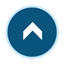](#contents)

# 🚧 Work in Progress

<!-- #### **✓** **T**imeliness: checked. -->

<br>

[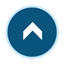](#contents)

<a id='references'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:left; font-weight:regular; overflow:hidden"><strong>References</strong></div>

**Case & Data**
* Google Data Analytics Professional Certificate • Capstone Project [🔗](https://www.coursera.org/learn/google-data-analytics-capstone/)
* 🚲 Chicago Divvy Bikeshare Dataset [🔗](https://www.kaggle.com/datasets/isissantoscosta/divvy-tripdata/)

**Techniques from other Kaggle users**
* Visualizing missing data: [Cyclistic Data Analysis](https://www.kaggle.com/code/sh184roman/cyclistic-data-analysis/), by [Roman Shrestha](https://www.kaggle.com/sh184roman)
* Too long, too short rides: [Cyclistic Case Study](https://www.kaggle.com/code/lukemorgan9/cyclistic-case-study/notebook), by [LukeMorgan9](https://www.kaggle.com/lukemorgan9/)

**User upgrade**
* How can you persuade customers to upgrade to a premium version of your product? [🔗](https://www.linkedin.com/advice/3/how-can-you-persuade-customers-upgrade-premium-oqeie#:~:text=You%20can%20use%20data%20analytics%2C%20surveys%2C%20interviews%2C,to%20tailor%20your%20messaging%20and%20positioning%20accordingly.)  
* How to improve user activation in 2025 [🔗](https://productfruits.com/blog/how-to-improve-user-activation/)

**Ideal Customer Profile (ICP)**
* What’s an Ideal Customer Profile (ICP)? How to Identify and Win Your Best Customers [🔗](https://www.salesforce.com/sales/ideal-customer-profile/)

**Spatial Analysis**
* What is geohashing? [🔗](https://www.pubnub.com/guides/what-is-geohashing/)
* H3: Uber’s Hexagonal Hierarchical Spatial Index [🔗](https://www.uber.com/us/en/blog/h3/)

**Dimensional Modeling**
* Kimball & Ross, The Data Warehouse Toolkit, 3rd ed. [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/books/data-warehouse-dw-toolkit/)
* Kimball Dimensional Modeling Techniques [🔗](https://www.kimballgroup.com/wp-content/uploads/2013/08/2013.09-Kimball-Dimensional-Modeling-Techniques11.pdf)
* Databricks • Understanding Star Schema [🔗](https://www.databricks.com/glossary/star-schema)
* Kimball Group • Dimensional Modeling Techniques [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/)
* Kimball Group • Four-Step Dimensional Design Process [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/four-4-step-design-process/)
* Kimball Group • Dimension Table Structure [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/dimension-table-structure/)
* Kimball Group • Fact Table Structure [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/fact-table-structure/)
* Kimball Group • Centipede Fact Table [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/centipede-fact-table/)
* Kimball Group • Role-Playing Dimensions [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/role-playing-dimension/)
* Vertabelo • Foreign Key (FK) [🔗](https://vertabelo.com/blog/what-is-foreign-key/)
* Vertabelo • Primary Key (PK) [🔗](https://vertabelo.com/blog/what-is-primary-key/)
* Kimball Group • Surrogate Keys [🔗](https://www.kimballgroup.com/1998/05/surrogate-keys/)
* Kimball Group • Dimension Surrogate Key [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/dimension-surrogate-key/) 
* Kimball Group • Degenerate Dimensions [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/kimball-techniques/dimensional-modeling-techniques/degenerate-dimension/)
* Kimball Group • Design Tip #46: Another Look At Degenerate Dimensions [🔗](https://www.kimballgroup.com/2003/06/design-tip-46-another-look-at-degenerate-dimensions/)
* Kimball Group • SCD, Slowly Changing Dimensions (Type 1 • Overwrite) [🔗](https://www.kimballgroup.com/2008/08/slowly-changing-dimensions/)
* SCD, Slowly Changing Dimensions (all techniques, Types 0 to 7) • Kimball & Ross, _The Data Warehouse Toolkit_, 3rd ed, pp. 53-56. [🔗](https://www.kimballgroup.com/data-warehouse-business-intelligence-resources/books/data-warehouse-dw-toolkit/)

**Data quality**
* Data Management Body of Knowledge (DMBoK) [🔗](https://technicspub.com/dmbok2/)
* Dimensions of Data Quality (DDQ) [🔗](https://www.dama-nl.org/wp-content/uploads/2020/09/DDQ-Dimensions-of-Data-Quality-Research-Paper-version-1.2-d.d.-3-Sept-2020.pdf)
* Code for Information Quality 2020 [🔗](https://www.dama-nl.org/wp-content/uploads/2020/02/Code-for-Information-Quality-2020-DAMA-EN_2_1.pdf)
* ISO 9001:2015 • Quality management systems[🔗](https://www.iso.org/standard/62085.html)
* ISO 80001:2022 • Data quality[🔗](https://www.iso.org/standard/81745.html)
* ISO 31000:2018 • Risk management[🔗](https://www.iso.org/standard/65694.html)
* COSO • ERM • Committee of Sponsoring Organizations Enterprise Risk Management[🔗](https://www.coso.org/guidance-erm)
* ITIL • Information Technology Infrastructure Library[🔗](https://www.itlibrary.org/)
* COBIT • Control Objectives for Information Technologies[🔗](https://www.isaca.org/resources/cobit)
* MIT TDQM • Total Data Quality Management Conceptual Framework[🔗](https://web.mit.edu/tdqm/www/tdqmpub/SURVEYIEEEKDEAug95.pdf)[🔗](https://www.researchgate.net/figure/Conceptual-Framework-of-Data-Quality-Wang-and-Strong-1996_fig2_254707240) by Wang et al. [🔗](https://www.linkedin.com/in/richard-wang-mitcdoiq/)[🔗](https://ieeexplore.ieee.org/author/37377595500)[🔗](https://dblp.org/pid/77/3485.html)
* U-Mich TDQ • University of Michigan Total Data Quality Framework[🔗](https://online.umich.edu/series/total-data-quality/) by Buskirk and colleagues[🔗](https://www.linkedin.com/in/tbuskirk/)[🔗](https://www.si.umich.edu/people/jinseok-kim/)[🔗](https://surveydatascience.isr.umich.edu/faculty-member/wagner/)[🔗](https://www.linkedin.com/in/brady-west-a769a73/)
* Modeling Data and Process Quality in Multi-Input, Multi-Output Information Systems [🔗](https://doi.org/10.1287/mnsc.31.2.150)
* Anchoring data quality dimensions in ontological foundations [🔗](https://dl.acm.org/doi/10.1145/240455.240479)
* The 6 dimensions of data quality, by Collibra [🔗](https://www.collibra.com/blog/the-6-dimensions-of-data-quality)

**Modular Design**
* Monolith, Modular, Mesh: modern architecture for modern data platforms [🔗](https://medium.com/@axel.westeinde/monolith-modular-mesh-modern-architecture-for-modern-data-platforms-2c0802ee0881)
* How to Move Beyond a Monolithic Data Lake to a Distributed Data Mesh • by Zhamak Dehghani [🔗](https://martinfowler.com/articles/data-monolith-to-mesh.html)
* How to Make Your Data Models Modular [🔗](https://medium.com/data-science/how-to-make-your-data-models-modular-71b21cdf5208)
* Building a Modular Data Architecture [🔗](https://www.prefect.io/blog/building-a-modular-data-architecture)
* dbt Labs • Data modeling techniques for more modularity [🔗](https://www.getdbt.com/blog/modular-data-modeling-techniques)

**Directed Acyclic Graph (DAG)**
* PopSQL • dbt DAG: Definition, Usage, and Examples [🔗](https://popsql.com/learn-dbt/dbt-dag)
* Hevo Data • Understanding dbt Dags: A Visual Guide for Data Lineage [🔗](https://hevodata.com/data-transformation/dbt-dag/)
* **dbt** Labs • DAG use cases and best practices [🔗](https://www.getdbt.com/blog/dag-use-cases-and-best-practices)

**Markdown**
* Tables in Markdown [🔗](https://docs.codeberg.org/markdown/tables-in-markdown/#:~:text=Markdown%20tables%20are%20written%20(%22drawn,%2C%20dash%20%2D%20and%20colon%20%3A%20.&text=The%20table%20columns%20do%20not,automatically%20align%20the%20table%20structure.)

**Python**
* pandas.DataFrame.unstack [🔗](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unstack.html)
* IPython.display.display [🔗](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.display)
* IPython.display.display_markdown [🔗](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.display_markdown)

<br>

[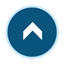](#contents)

<a id='annex'></a>

# <div style="background-color:#03002e; padding:18px; border-radius:8px; color:white; text-align:left; font-weight:regular; overflow:hidden"><strong>Annex • User upgrade strategies</strong></div>

The following is a list of **key actions** that can be taken **to get users to upgrade**, extracted from the "LinkedIn Advice" discussion:  
[_How can you persuade customers to upgrade to a premium version of your product?_](https://www.google.com/search?q=https://linkedin.com/advice/3/how-can-you-persuade-customers-upgrade-premium-oqeie)".  

> Strive to persuade customers, and they will feel manipulated and leave you.  
> **Reduce time to value and surprise them with outstanding experience, they will remain loyal and upgrade.**  
> Great services will keep customers. Ensure you delight them and they will have plenty of reasons to upgrade.
>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[**David Pereira**](https://www.linkedin.com/in/davidavpereira/?trk=article-ssr-frontend-x-article), Product Coach & Speaker

---

**General / Cross-Functional Strategies**  
* The **« who »** → Understand your customers  
* The **« who »** → Identify needs, pain points, usage patterns  
* The **« who »** → Segment based on behavior, demographics, readiness to upgrade  
* The **« who »** → Gather feedback through data analytics, surveys, interviews, usability testing  
* Value proposition → Articulate benefits and ROI  
* Value proposition → Focus on how the upgrade solve specific user problems or enhance their experience  
* Value proposition → Showcase  
* Communication → Tailor messaging and positioning to different user segments  
* Communication → Use clear, concise language  
* Communication → Communicate benefits, not just features  
* Upgrade paths → Make upgrade process seamless and intuitive  
* Upgrade paths → Provide in-app prompts and notifications  

**Product**
* Tiered pricing → Design increasing value for higher plans  
* Tiered pricing → Ensure a clear differentiation between tiers  
* Tiered pricing → Enable gating and trials  
* Limited-time trials → Gate advanced features behind the premium tier  
* Limited-time trials → Optimize user experience (UX)  
* Limited-time trials → Ensure the basic product provides core value to keep users engaged  
* Limited-time trials → Design smooth, intuitive upgrade flow  
* Usage-based value → If applicable, highlight how users are approaching plan limits  
* Usage-based value → Provide insights into potential benefits from increased limits or advanced features  

**Marketing**
* Targeted campaigns → Email, in-app messages, push notifications  
* Targeted campaigns → Use retargeting ads for users who have shown interest in premium features  
* Content marketing → Create case studies, testimonials, and success stories showcasing premium benefits  
* Content marketing → Develop educational content that demonstrates how premium features solve advanced problems  
* Promotional offers → Offer incentives for upgrading  
* Leverage social proof → Highlight the number of users already on premium plans or positive reviews  

**Sales / Customer Success**
* Proactive outreach → Identify power users or those hitting limits on free/basic plans and reach out with tailored upgrade offers
* Proactive outreach → Conduct business reviews with existing customers to identify growth opportunities  
* Education and support → Ensure customer support teams are knowledgeable about premium features and can articulate their value  
* Education and support → Provide training or onboarding for new premium features

<br>

[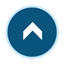](#contents)

<a id='wrapup'></a>

<div style="overflow: hidden; width: 100%;">
<div style="font-size:26px; background-color:#03002e; padding:27px; border-radius:8px; color:white; text-align:left; font-weight:regular; overflow:hidden"><strong>Wrap-up</strong></div>

### Note on 👩‍💻🤖 (AI-Assisted) work

This notebook is labeled AI-Augmented.  
Across my work, I use the following convention:

* **AI-Assisted**<br>
Work authored end-to-end by me, with AI used for peer review.

* **AI-Augmented**<br>
Work in which AI contributes beyond review, generating query templates, code blocks, or initial text excerpts that are then adapted, integrated, and validated by me.

</div>

---

### 👥 Credits

**Engineer** • Ísis Santos Costa 

↳ **Principal Peer Reviewer** • Gemini   
↳ **Peer Reviewer (full-time)** • ChatGPT  
↳ **Peer Reviewer (part-time)** • Claude, Anthropic AI  

This notebook demonstrates human-AI collaboration for analytics.

---

<h6 style="background-color:#03002e; padding:12px; border-radius:8px; color:white; text-align:center; font-weight:bold; font-size:150%; font-style:normal;">
    <strong>See you on the next coding!</strong><br>
    <font style='font-size:55%; font-weight:thin; font-style:italic;'>(yours or mine) (or ours!)</font>
</h6>